# S&P 500 Corporate Performance Intelligence Report
### Operational Efficiency × Financial Health × Valuation Analysis

**Author:** Samuel Manson
**Date:** February 2026
**Data Sources:** GitHub (S&P 500 Constituents & Financials), Kaggle (72-Indicator Performance Dataset)

---

**Business Question:** *Across the S&P 500, which sectors and companies are running the most efficient operations, which are financially healthy, and where does the market's valuation not match the fundamentals?*

**Project Structure:**
- **Phase 1:** Data Preparation, Cleaning & Multi-Source Integration
- **Phase 2:** Operational Efficiency Analysis & Scoring
- **Phase 3:** Financial Health Assessment & Risk Tiering
- **Phase 4:** Valuation Gap Analysis
- **Phase 5:** Executive Dashboard & Strategic Insights

In [22]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Phase 1: Data Preparation, Cleaning & Multi-Source Integration

This phase demonstrates a core analyst skill: Integrating data from multiple sources, cleaning inconsistent formats, and building a unified dataset ready for analysis. We work with three tables:

| Table | Source | Role | Records |
|-------|--------|------|---------|
| `constituents` | GitHub | Dimension/Lookup (Symbol, Name, Sector) | 503 |
| `constituents_financials` | GitHub | Market Valuation Metrics | 503 |
| `kaggle_performance` | Kaggle | Deep Operational & Financial Performance (72 indicators) | 496 |

**Key Challenges:**
- Kaggle dataset stores all values as strings with B/M/K suffixes, % signs, and dashes for nulls
- Join keys use different column names across sources
- Sub-industry labels (127 unique) need mapping to 11 GICS sectors for sector-level analysis
- Overlapping columns across datasets require reconciliation

### 1.1 — Import & Load Raw Data

In [24]:
# Upload datasets to Colab
from google.colab import files
uploaded = files.upload()

Saving filtered_data.csv to filtered_data (4).csv
Saving filtered_data (1).csv to filtered_data (1) (3).csv
Saving snp500_companies_description.csv to snp500_companies_description (3).csv


In [25]:
import os
for f in os.listdir('.'):
    if f.endswith('.csv'):
        print(f)

filtered_data.csv
snp500_companies_description (2).csv
filtered_data (4).csv
filtered_data (1).csv
filtered_data (1) (3).csv
filtered_data (3).csv
filtered_data (1) (1).csv
filtered_data (2).csv
snp500_companies_description (1).csv
filtered_data (1) (2).csv
snp500_companies_description.csv
snp500_companies_description (3).csv


In [28]:
import pandas as pd

files_to_check = [
    'filtered_data.csv',
    'filtered_data (1).csv',
    'filtered_data (2).csv',
    'snp500_companies_description.csv'
]

for f in files_to_check:
    try:
        temp = pd.read_csv(f)
        print(f'{f}  →  {temp.shape[0]} rows × {temp.shape[1]} columns  →  Cols: {list(temp.columns[:4])}')
    except:
        print(f'{f}  →  ERROR')

filtered_data.csv  →  503 rows × 3 columns  →  Cols: ['Symbol', 'Name', 'Sector']
filtered_data (1).csv  →  503 rows × 14 columns  →  Cols: ['Symbol', 'Name', 'Sector', 'Price']
filtered_data (2).csv  →  503 rows × 3 columns  →  Cols: ['Symbol', 'Name', 'Sector']
snp500_companies_description.csv  →  496 rows × 73 columns  →  Cols: ['Company', 'Major index membership', 'Market capitalization', 'Income (ttm)']


In [ ]:
# Load all three datasets
df_dim = pd.read_csv('filtered_data.csv')                        # Table 1: Dimension (3 cols)
df_val = pd.read_csv('filtered_data (1).csv')                    # Table 2: Valuation (14 cols)
df_perf = pd.read_csv('snp500_companies_description.csv')        # Table 3: Performance (Kaggle)

print(f'Table 1 — Constituents (Dimension):  {df_dim.shape[0]} rows × {df_dim.shape[1]} columns')
print(f'Table 2 — Financials (Valuation):    {df_val.shape[0]} rows × {df_val.shape[1]} columns')
print(f'Table 3 — Performance (Kaggle):      {df_perf.shape[0]} rows × {df_perf.shape[1]} columns')
print(f'\nTotal raw features across all sources: {df_dim.shape[1] + df_val.shape[1] + df_perf.shape[1]}')

### 1.2 — Initial Data Inspection

In [29]:
# Table 1: Dimension table — simple lookup
print('=== TABLE 1: Constituents (Dimension) ===')
print(f'Columns: {list(df_dim.columns)}')
print(f'Null values: {df_dim.isnull().sum().sum()}')
print(f'Unique sub-industries: {df_dim["Sector"].nunique()}')
df_dim.head()

=== TABLE 1: Constituents (Dimension) ===
Columns: ['Symbol', 'Name', 'Sector']
Null values: 0
Unique sub-industries: 127


,Symbol,Name,Sector
0,MMM,3M,Industrial Conglomerates
1,AOS,A. O. Smith,Building Products
2,ABT,Abbott Laboratories,Health Care Equipment
3,ABBV,AbbVie,Biotechnology
4,ACN,Accenture,IT Consulting & Other Services


In [30]:
# Table 2: Valuation data — already numeric, some nulls
print('=== TABLE 2: Financials (Valuation) ===')
print(f'Columns: {list(df_val.columns)}')
print(f'\nData types:')
print(df_val.dtypes)
print(f'\nNull counts:')
print(df_val.isnull().sum())
df_val.head()

=== TABLE 2: Financials (Valuation) ===
Columns: ['Symbol', 'Name', 'Sector', 'Price', 'Price/Earnings', 'Dividend Yield', 'Earnings/Share', '52 Week Low', '52 Week High', 'Market Cap', 'EBITDA', 'Price/Sales', 'Price/Book', 'SEC Filings']

Data types:
Symbol             object
Name               object
Sector             object
Price             float64
Price/Earnings    float64
Dividend Yield    float64
Earnings/Share    float64
52 Week Low       float64
52 Week High      float64
Market Cap        float64
EBITDA            float64
Price/Sales       float64
Price/Book        float64
SEC Filings        object
dtype: object

Null counts:
Symbol             0
Name               0
Sector             0
Price              3
Price/Earnings    28
Dividend Yield    99
Earnings/Share     4
52 Week Low        3
52 Week High       3
Market Cap         3
EBITDA            33
Price/Sales        4
Price/Book        35
SEC Filings        0
dtype: int64


,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings
0,MMM,3M,Industrial Conglomerates,152.20,21.29,0.02,7.15,75.65,155.00,"83,294,183,424.00","8,117,000,192.00",2.55,17.86,http://www.sec.gov/cgi-bin/browse-edgar?action...
1,AOS,A. O. Smith,Building Products,67.30,18.54,0.02,3.63,66.76,92.45,"9,758,164,992.00","809,100,032.00",2.51,5.09,http://www.sec.gov/cgi-bin/browse-edgar?action...
2,ABT,Abbott Laboratories,Health Care Equipment,127.93,16.74,0.02,7.64,99.71,129.85,"221,889,478,656.00","10,824,999,936.00",5.38,5.58,http://www.sec.gov/cgi-bin/browse-edgar?action...
3,ABBV,AbbVie,Biotechnology,183.90,64.30,0.04,2.86,153.58,207.32,"324,977,033,216.00","25,629,999,104.00",5.85,53.88,http://www.sec.gov/cgi-bin/browse-edgar?action...
4,ACN,Accenture,IT Consulting & Other Services,384.95,32.29,0.02,11.92,278.69,387.51,"240,778,526,720.00","11,065,912,320.00",3.71,8.51,http://www.sec.gov/cgi-bin/browse-edgar?action...


In [ ]:
# Table 3: Kaggle performance data — ALL columns stored as strings
print('=== TABLE 3: Performance (Kaggle) ===')
print(f'Columns ({df_perf.shape[1]} total):')
for i, col in enumerate(df_perf.columns):
    print(f'  {i+1:2d}. {col}')
print(f'\nAll dtypes are: {df_perf.dtypes.unique()}')
print(f'\nSample values:')
df_perf[['Symbol', 'Market capitalization', 'Revenue (ttm)',
         'Return on Equity (ttm)', 'Gross Margin (ttm)', 'Current Ratio (mrq)']].head(3)

### 1.3 — Join Key Analysis

With three separate data sources, the first step before any cleaning is to validate that the join keys align. All three tables use ticker symbols as identifiers, but naming conventions differ — GitHub uses `Symbol` while Kaggle labels it `Company`. We also need to check for mismatches that will impact our final record count.

In [31]:
# Standardize join key naming
df_perf = df_perf.rename(columns={'Company': 'Symbol'})

# Strip whitespace from all join keys
df_dim['Symbol'] = df_dim['Symbol'].str.strip()
df_val['Symbol'] = df_val['Symbol'].str.strip()
df_perf['Symbol'] = df_perf['Symbol'].str.strip()

# Join key overlap analysis
symbols_dim = set(df_dim['Symbol'])
symbols_val = set(df_val['Symbol'])
symbols_perf = set(df_perf['Symbol'])

print('Join Key Overlap Analysis:')
print(f'  Table 1 unique symbols:    {len(symbols_dim)}')
print(f'  Table 2 unique symbols:    {len(symbols_val)}')
print(f'  Table 3 unique symbols:    {len(symbols_perf)}')
print(f'  Table 1 ∩ Table 2:         {len(symbols_dim & symbols_val)} (perfect match)')
print(f'  Table 1 ∩ Table 3:         {len(symbols_dim & symbols_perf)}')
print(f'  All three overlap:         {len(symbols_dim & symbols_val & symbols_perf)}')
print(f'\n  Companies in GitHub but NOT Kaggle: {len(symbols_dim - symbols_perf)}')
print(f'  Companies in Kaggle but NOT GitHub:  {len(symbols_perf - symbols_dim)}')
print(f'\n  Join strategy: LEFT JOIN on GitHub base ({len(symbols_dim)} records)')
print(f'  Expected null Kaggle records: {len(symbols_dim - symbols_perf)}')

Join Key Overlap Analysis:
  Table 1 unique symbols:    503
  Table 2 unique symbols:    503
  Table 3 unique symbols:    496
  Table 1 ∩ Table 2:         503 (perfect match)
  Table 1 ∩ Table 3:         454
  All three overlap:         454

  Companies in GitHub but NOT Kaggle: 49
  Companies in Kaggle but NOT GitHub:  42

  Join strategy: LEFT JOIN on GitHub base (503 records)
  Expected null Kaggle records: 49


### 1.4 — Data Cleaning: Table 2 (Valuation)

The valuation table is relatively clean — pandas correctly inferred numeric types on import. The main task here is removing redundant columns that will come through the dimension table join, and documenting null counts for downstream handling.

In [32]:
# Drop redundant columns (Name, Sector come from dimension table; SEC Filings not analytical)
df_val_clean = df_val.drop(columns=['Name', 'Sector', 'SEC Filings'])

print(f'Valuation table: {df_val_clean.shape[0]} rows × {df_val_clean.shape[1]} columns')
print(f'\nRetained columns: {list(df_val_clean.columns)}')
print(f'\nNull summary:')
null_report = df_val_clean.isnull().sum()
null_report = null_report[null_report > 0]
for col, count in null_report.items():
    print(f'  {col}: {count} nulls ({count/len(df_val_clean)*100:.1f}%)')

Valuation table: 503 rows × 11 columns

Retained columns: ['Symbol', 'Price', 'Price/Earnings', 'Dividend Yield', 'Earnings/Share', '52 Week Low', '52 Week High', 'Market Cap', 'EBITDA', 'Price/Sales', 'Price/Book']

Null summary:
  Price: 3 nulls (0.6%)
  Price/Earnings: 28 nulls (5.6%)
  Dividend Yield: 99 nulls (19.7%)
  Earnings/Share: 4 nulls (0.8%)
  52 Week Low: 3 nulls (0.6%)
  52 Week High: 3 nulls (0.6%)
  Market Cap: 3 nulls (0.6%)
  EBITDA: 33 nulls (6.6%)
  Price/Sales: 4 nulls (0.8%)
  Price/Book: 35 nulls (7.0%)


### 1.5 — Data Cleaning: Table 3 (Kaggle Performance)

The Kaggle dataset required the most extensive cleaning — all 72 columns imported as strings due to mixed formatting (B/M/K suffixes, percentage symbols, dashes as nulls, comma separators). I built three conversion functions to handle each format type systematically.

In [33]:
# --- Conversion Functions ---

def convert_dollar_suffix(val):
    """Convert string values with B/M/K suffixes to numeric.
    Examples: '41.05B' → 41050000000, '127.00M' → 127000000"""
    if pd.isna(val) or str(val).strip() in ['-', '']:
        return np.nan
    val = str(val).strip()
    try:
        if val.endswith('B'):
            return float(val[:-1]) * 1e9
        elif val.endswith('M'):
            return float(val[:-1]) * 1e6
        elif val.endswith('K'):
            return float(val[:-1]) * 1e3
        return float(val.replace(',', ''))
    except (ValueError, TypeError):
        return np.nan


def convert_percentage(val):
    """Convert percentage strings to decimal floats.
    Examples: '25.00%' → 0.25, '-1.60%' → -0.016"""
    if pd.isna(val) or str(val).strip() in ['-', '']:
        return np.nan
    val = str(val).strip()
    try:
        if val.endswith('%'):
            return float(val[:-1]) / 100
        return float(val)
    except (ValueError, TypeError):
        return np.nan


def convert_numeric(val):
    """Convert plain numeric strings (handles commas and dashes).
    Examples: '312,065' → 312065, '-' → NaN, '2.10' → 2.10"""
    if pd.isna(val) or str(val).strip() in ['-', '']:
        return np.nan
    try:
        return float(str(val).strip().replace(',', ''))
    except (ValueError, TypeError):
        return np.nan


print('Conversion functions loaded.')

Conversion functions loaded.


In [35]:
# --- Classify columns by their format type ---

dollar_columns = [
    'Market capitalization', 'Income (ttm)', 'Revenue (ttm)',
    'Dividend (annual)', 'Short interest', "Analysts' mean target price",
    'Shares outstanding', 'Shares float'
]

percentage_columns = [
    'Dividend yield (annual)',
    'Distance from 20-Day Simple Moving Average',
    'Distance from 50-Day Simple Moving Average',
    'Distance from 200-Day Simple Moving Average',
    'Distance from 52-Week High', 'Distance from 52-Week Low',
    'EPS growth this year', 'EPS growth next year',
    'Long term annual growth estimate (5 years)',
    'Annual EPS growth past 5 years', 'Annual sales growth past 5 years',
    'Quarterly revenue growth (YoY)', 'Quarterly earnings growth (YoY)',
    'Insider ownership',
    'Insider transactions (6-Month change in Insider Ownership)',
    'Institutional ownership',
    'Institutional transactions (3-Month change in Institutional Ownership)',
    'Return on Assets (ttm)', 'Return on Equity (ttm)', 'Return on Investment (ttm)',
    'Gross Margin (ttm)', 'Operating Margin (ttm)', 'Net Profit Margin (ttm)',
    'Dividend Payout Ratio (ttm)',
    'Performance (Week)', 'Performance (Month)', 'Performance (Quarter)',
    'Performance (Half Year)', 'Performance (Year)', 'Performance (Year To Date)',
    'Performance (today)'
]

numeric_columns = [
    'Book value per share (mrq)', 'Cash per share (mrq)',
    "Analysts' mean recommendation (1=Buy 5=Sell)",
    'Price-to-Earnings (ttm)', 'Forward Price-to-Earnings (next fiscal year)',
    'Price-to-Earnings-to-Growth', 'Price-to-Sales (ttm)', 'Price-to-Book (mrq)',
    'Price to cash per share (mrq)', 'Price to Free Cash Flow (ttm)',
    'Quick Ratio (mrq)', 'Current Ratio (mrq)',
    'Total Debt to Equity (mrq)', 'Long Term Debt to Equity (mrq)',
    'Diluted EPS (ttm)', 'EPS estimate for next year', 'EPS estimate for next quarter',
    'Full time employees',
    'Relative Strength Index', 'Relative volume',
    'Average volume (3 month)', 'Volume',
    'Beta', 'Average True Range (14)',
    'Previous close', 'Current stock price'
]

print(f'Column classification:')
print(f'  Dollar/suffix columns:  {len(dollar_columns)}')
print(f'  Percentage columns:     {len(percentage_columns)}')
print(f'  Plain numeric columns:  {len(numeric_columns)}')
print(f'  Total to convert:       {len(dollar_columns) + len(percentage_columns) + len(numeric_columns)}')

Column classification:
  Dollar/suffix columns:  8
  Percentage columns:     31
  Plain numeric columns:  26
  Total to convert:       65


In [36]:
# --- Apply conversions ---

for col in dollar_columns:
    if col in df_perf.columns:
        df_perf[col] = df_perf[col].apply(convert_dollar_suffix)

for col in percentage_columns:
    if col in df_perf.columns:
        df_perf[col] = df_perf[col].apply(convert_percentage)

for col in numeric_columns:
    if col in df_perf.columns:
        df_perf[col] = df_perf[col].apply(convert_numeric)

# Verify conversion results
float_count = (df_perf.dtypes == 'float64').sum()
object_count = (df_perf.dtypes == 'object').sum()
print(f'After conversion:')
print(f'  Float columns:  {float_count}')
print(f'  String columns: {object_count}')
print(f'\nSample converted values:')
df_perf[['Symbol', 'Market capitalization', 'Revenue (ttm)',
         'Return on Equity (ttm)', 'Gross Margin (ttm)', 'Current Ratio (mrq)']].head(3)

After conversion:
  Float columns:  65
  String columns: 8

Sample converted values:


,Symbol,Market capitalization,Revenue (ttm),Return on Equity (ttm),Gross Margin (ttm),Current Ratio (mrq)
0,A,"41,050,000,000.00","6,930,000,000.00",0.25,0.55,2.10
1,AAL,"10,650,000,000.00","48,970,000,000.00",-0.02,0.58,0.70
2,AAP,"7,880,000,000.00","11,150,000,000.00",0.18,0.45,1.10


In [37]:
# --- Drop columns not needed for analysis ---

cols_to_drop = [
    'Major index membership',                          # All S&P 500, no variance
    'Stock has options trading on a market exchange',   # Binary, not relevant
    'Stock available to sell short',                    # Binary, not relevant
    '52-Week trading range',                           # String range, we have High/Low separately
    'Short interest share / ratio',                    # Complex string format
]

# Earnings date column has HTML formatting in the name — find it dynamically
earnings_col = [c for c in df_perf.columns if 'Earnings date' in c]
cols_to_drop.extend(earnings_col)

# Volatility column has parsing issues — find and remove
vol_col = [c for c in df_perf.columns if 'Volatility' in c]
cols_to_drop.extend(vol_col)

df_perf_clean = df_perf.drop(columns=[c for c in cols_to_drop if c in df_perf.columns])

print(f'Dropped {len([c for c in cols_to_drop if c in df_perf.columns])} non-analytical columns.')
print(f'Kaggle dataset: {df_perf_clean.shape[0]} rows × {df_perf_clean.shape[1]} columns')

Dropped 7 non-analytical columns.
Kaggle dataset: 496 rows × 66 columns


### 1.6 — GICS Sector Mapping

The dimension table contains 127 unique GICS sub-industries. For meaningful sector-level benchmarking, these need to roll up to the 11 standard GICS sectors.

In [38]:
# GICS Sub-Industry → Sector Mapping
gics_mapping = {
    # Information Technology
    'Application Software': 'Information Technology',
    'Communications Equipment': 'Information Technology',
    'Data Processing & Outsourced Services': 'Information Technology',
    'Electronic Components': 'Information Technology',
    'Electronic Equipment & Instruments': 'Information Technology',
    'Electronic Manufacturing Services': 'Information Technology',
    'IT Consulting & Other Services': 'Information Technology',
    'Semiconductor Materials & Equipment': 'Information Technology',
    'Semiconductors': 'Information Technology',
    'Systems Software': 'Information Technology',
    'Technology Distributors': 'Information Technology',
    'Technology Hardware, Storage & Peripherals': 'Information Technology',

    # Health Care
    'Biotechnology': 'Health Care',
    'Health Care Distributors': 'Health Care',
    'Health Care Equipment': 'Health Care',
    'Health Care Facilities': 'Health Care',
    'Health Care Services': 'Health Care',
    'Health Care Supplies': 'Health Care',
    'Health Care Technology': 'Health Care',
    'Life Sciences Tools & Services': 'Health Care',
    'Managed Health Care': 'Health Care',
    'Pharmaceuticals': 'Health Care',

    # Financials
    'Asset Management & Custody Banks': 'Financials',
    'Consumer Finance': 'Financials',
    'Diversified Banks': 'Financials',
    'Financial Exchanges & Data': 'Financials',
    'Insurance Brokers': 'Financials',
    'Investment Banking & Brokerage': 'Financials',
    'Life & Health Insurance': 'Financials',
    'Multi-line Insurance': 'Financials',
    'Multi-Sector Holdings': 'Financials',
    'Property & Casualty Insurance': 'Financials',
    'Regional Banks': 'Financials',
    'Reinsurance': 'Financials',
    'Transaction & Payment Processing Services': 'Financials',

    # Consumer Discretionary
    'Apparel Retail': 'Consumer Discretionary',
    'Apparel, Accessories & Luxury Goods': 'Consumer Discretionary',
    'Automobile Manufacturers': 'Consumer Discretionary',
    'Automotive Parts & Equipment': 'Consumer Discretionary',
    'Automotive Retail': 'Consumer Discretionary',
    'Broadline Retail': 'Consumer Discretionary',
    'Casinos & Gaming': 'Consumer Discretionary',
    'Computer & Electronics Retail': 'Consumer Discretionary',
    'Consumer Electronics': 'Consumer Discretionary',
    'Footwear': 'Consumer Discretionary',
    'Home Furnishings': 'Consumer Discretionary',
    'Home Improvement Retail': 'Consumer Discretionary',
    'Homebuilding': 'Consumer Discretionary',
    'Hotels, Resorts & Cruise Lines': 'Consumer Discretionary',
    'Interactive Home Entertainment': 'Consumer Discretionary',
    'Leisure Products': 'Consumer Discretionary',
    'Movies & Entertainment': 'Consumer Discretionary',
    'Other Specialty Retail': 'Consumer Discretionary',
    'Restaurants': 'Consumer Discretionary',

    # Consumer Staples
    'Agricultural Products & Services': 'Consumer Staples',
    'Brewers': 'Consumer Staples',
    'Consumer Staples Merchandise Retail': 'Consumer Staples',
    'Distillers & Vintners': 'Consumer Staples',
    'Drug Retail': 'Consumer Staples',
    'Food Distributors': 'Consumer Staples',
    'Food Retail': 'Consumer Staples',
    'Household Products': 'Consumer Staples',
    'Packaged Foods & Meats': 'Consumer Staples',
    'Personal Care Products': 'Consumer Staples',
    'Soft Drinks & Non-alcoholic Beverages': 'Consumer Staples',
    'Tobacco': 'Consumer Staples',

    # Industrials
    'Aerospace & Defense': 'Industrials',
    'Agricultural & Farm Machinery': 'Industrials',
    'Air Freight & Logistics': 'Industrials',
    'Building Products': 'Industrials',
    'Cargo Ground Transportation': 'Industrials',
    'Construction & Engineering': 'Industrials',
    'Construction Machinery & Heavy Transportation Equipment': 'Industrials',
    'Diversified Support Services': 'Industrials',
    'Electrical Components & Equipment': 'Industrials',
    'Environmental & Facilities Services': 'Industrials',
    'Heavy Electrical Equipment': 'Industrials',
    'Human Resource & Employment Services': 'Industrials',
    'Industrial Conglomerates': 'Industrials',
    'Industrial Machinery & Supplies & Components': 'Industrials',
    'Passenger Airlines': 'Industrials',
    'Passenger Ground Transportation': 'Industrials',
    'Rail Transportation': 'Industrials',
    'Research & Consulting Services': 'Industrials',
    'Trading Companies & Distributors': 'Industrials',

    # Energy
    'Independent Power Producers & Energy Traders': 'Energy',
    'Integrated Oil & Gas': 'Energy',
    'Oil & Gas Equipment & Services': 'Energy',
    'Oil & Gas Exploration & Production': 'Energy',
    'Oil & Gas Refining & Marketing': 'Energy',
    'Oil & Gas Storage & Transportation': 'Energy',

    # Utilities
    'Electric Utilities': 'Utilities',
    'Gas Utilities': 'Utilities',
    'Multi-Utilities': 'Utilities',
    'Water Utilities': 'Utilities',

    # Real Estate
    'Data Center REITs': 'Real Estate',
    'Health Care REITs': 'Real Estate',
    'Hotel & Resort REITs': 'Real Estate',
    'Industrial REITs': 'Real Estate',
    'Multi-Family Residential REITs': 'Real Estate',
    'Office REITs': 'Real Estate',
    'Other Specialized REITs': 'Real Estate',
    'Real Estate Services': 'Real Estate',
    'Retail REITs': 'Real Estate',
    'Self-Storage REITs': 'Real Estate',
    'Single-Family Residential REITs': 'Real Estate',
    'Telecom Tower REITs': 'Real Estate',
    'Timber REITs': 'Real Estate',

    # Communication Services
    'Advertising': 'Communication Services',
    'Broadcasting': 'Communication Services',
    'Cable & Satellite': 'Communication Services',
    'Integrated Telecommunication Services': 'Communication Services',
    'Interactive Media & Services': 'Communication Services',
    'Internet Services & Infrastructure': 'Communication Services',
    'Publishing': 'Communication Services',
    'Wireless Telecommunication Services': 'Communication Services',

    # Materials
    'Commodity Chemicals': 'Materials',
    'Construction Materials': 'Materials',
    'Copper': 'Materials',
    'Distributors': 'Materials',
    'Fertilizers & Agricultural Chemicals': 'Materials',
    'Gold': 'Materials',
    'Industrial Gases': 'Materials',
    'Metal, Glass & Plastic Containers': 'Materials',
    'Paper & Plastic Packaging Products & Materials': 'Materials',
    'Specialty Chemicals': 'Materials',
    'Steel': 'Materials',
}

# Apply mapping and validate
df_dim['GICS_Sector'] = df_dim['Sector'].map(gics_mapping)

unmapped = df_dim[df_dim['GICS_Sector'].isna()]['Sector'].unique()
if len(unmapped) > 0:
    print(f'WARNING — Unmapped sub-industries: {unmapped}')
else:
    print('All 127 sub-industries successfully mapped to GICS sectors.')

# Rename original column for clarity
df_dim = df_dim.rename(columns={'Sector': 'Sub_Industry'})

print(f'\nGICS Sector Distribution:')
print(df_dim['GICS_Sector'].value_counts())

All 127 sub-industries successfully mapped to GICS sectors.

GICS Sector Distribution:
GICS_Sector
Industrials               77
Financials                72
Information Technology    66
Health Care               62
Consumer Discretionary    53
Consumer Staples          38
Materials                 31
Real Estate               31
Utilities                 29
Energy                    24
Communication Services    20
Name: count, dtype: int64


### 1.7 — Multi-Source Data Integration (Three-Table Join)

With all three tables cleaned and standardized, I performed a two-step join using ticker symbol as the key. Tables 1 and 2 share a perfect 503-record match (INNER JOIN), while Table 3 covers 454 of those companies (LEFT JOIN to preserve full coverage).

In [44]:
# Step 1: INNER JOIN — Dimension + Valuation
df_merged = pd.merge(df_dim, df_val_clean, on='Symbol', how='inner')
print(f'Step 1 — Dimension + Valuation: {df_merged.shape[0]} rows × {df_merged.shape[1]} columns')

# Step 2: LEFT JOIN — Add Kaggle Performance data
df_final = pd.merge(df_merged, df_perf_clean, on='Symbol', how='left')
print(f'Step 2 — + Kaggle Performance:  {df_final.shape[0]} rows × {df_final.shape[1]} columns')

# Coverage check
has_kaggle = df_final['Return on Equity (ttm)'].notna().sum()
print(f'\nCompanies with full 3-source data: {has_kaggle} / {len(df_final)} ({has_kaggle/len(df_final)*100:.1f}%)')

Step 1 — Dimension + Valuation: 503 rows × 14 columns
Step 2 — + Kaggle Performance:  503 rows × 79 columns

Companies with full 3-source data: 446 / 503 (88.7%)


In [45]:
# Verify the joined dataset
print(f'Final Dataset Overview:')
print(f'  Companies:  {df_final.shape[0]}')
print(f'  Features:   {df_final.shape[1]}')
print(f'  GICS Sectors: {df_final["GICS_Sector"].nunique()}')
print(f'\nDimension fields: 4 | Valuation metrics: {len(df_val_clean.columns) - 1} | Kaggle metrics: {len(df_perf_clean.columns) - 1}')
print(f'\nSample:')

Final Dataset Overview:
  Companies:  503
  Features:   79
  GICS Sectors: 11

Dimension fields: 4 | Valuation metrics: 10 | Kaggle metrics: 65

Sample:


### 1.8 — Feature Engineering

Built six calculated fields to support the scoring models in Phases 2-4. These composite metrics translate raw financial data into actionable indicators for efficiency, valuation, and growth analysis.

In [46]:
# --- Engineered Features ---

# 1. Price Position within 52-Week Range (0 = at low, 1 = at high)
df_final['Price_52W_Position'] = (
    (df_final['Price'] - df_final['52 Week Low']) /
    (df_final['52 Week High'] - df_final['52 Week Low'])
)

# 2. EBITDA-to-Market Cap ratio (proxy for earnings efficiency relative to valuation)
df_final['EBITDA_to_MarketCap'] = df_final['EBITDA'] / df_final['Market Cap']

# 3. Earnings Yield (inverse of P/E — higher = cheaper relative to earnings)
df_final['Earnings_Yield'] = 1 / df_final['Price/Earnings']

# 4. Valuation Composite (z-score average of P/E, P/B, P/S — lower = cheaper)
for col in ['Price/Earnings', 'Price/Book', 'Price/Sales']:
    col_name = f'{col}_zscore'
    mean = df_final[col].mean()
    std = df_final[col].std()
    df_final[col_name] = (df_final[col] - mean) / std

df_final['Valuation_Composite_Z'] = df_final[[
    'Price/Earnings_zscore', 'Price/Book_zscore', 'Price/Sales_zscore'
]].mean(axis=1)

# 5. Growth Score (average of key growth indicators)
growth_cols = ['Quarterly revenue growth (YoY)', 'Quarterly earnings growth (YoY)',
               'EPS growth this year', 'Annual sales growth past 5 years']
df_final['Growth_Score'] = df_final[[c for c in growth_cols if c in df_final.columns]].mean(axis=1)

# 6. Profitability Score (average of ROE, ROA, ROI)
prof_cols = ['Return on Equity (ttm)', 'Return on Assets (ttm)', 'Return on Investment (ttm)']
df_final['Profitability_Score'] = df_final[[c for c in prof_cols if c in df_final.columns]].mean(axis=1)

# Summary
new_features = ['Price_52W_Position', 'EBITDA_to_MarketCap', 'Earnings_Yield',
                'Valuation_Composite_Z', 'Growth_Score', 'Profitability_Score']
print('Engineered Features:')
for feat in new_features:
    non_null = df_final[feat].notna().sum()
    print(f'  {feat}: {non_null} non-null ({non_null/len(df_final)*100:.0f}% coverage)')

Engineered Features:
  Price_52W_Position: 500 non-null (99% coverage)
  EBITDA_to_MarketCap: 470 non-null (93% coverage)
  Earnings_Yield: 475 non-null (94% coverage)
  Valuation_Composite_Z: 500 non-null (99% coverage)
  Growth_Score: 454 non-null (90% coverage)
  Profitability_Score: 451 non-null (90% coverage)


### 1.9 — Data Quality Report

Final assessment of the cleaned, joined dataset before moving into analysis.

In [48]:
# Comprehensive null analysis
null_summary = pd.DataFrame({
    'Null_Count': df_final.isnull().sum(),
    'Null_Pct': (df_final.isnull().sum() / len(df_final) * 100).round(1),
    'Dtype': df_final.dtypes
}).sort_values('Null_Pct', ascending=False)

print(f'=== DATA QUALITY REPORT ===')
print(f'Total records:        {len(df_final)}')
print(f'Total features:       {df_final.shape[1]}')
print(f'GICS Sectors:         {df_final["GICS_Sector"].nunique()}')
print(f'\nCompleteness by threshold:')
print(f'  100% complete:      {(null_summary["Null_Pct"] == 0).sum()} columns')
print(f'  >90% complete:      {(null_summary["Null_Pct"] < 10).sum()} columns')
print(f'  >80% complete:      {(null_summary["Null_Pct"] < 20).sum()} columns')
print(f'  >70% complete:      {(null_summary["Null_Pct"] < 30).sum()} columns')
print(f'\nColumns with >15% missing:')
high_null = null_summary[null_summary['Null_Pct'] > 15]
if len(high_null) > 0:
    print(high_null[['Null_Count', 'Null_Pct']])

=== DATA QUALITY REPORT ===
Total records:        503
Total features:       88
GICS Sectors:         11

Completeness by threshold:
  100% complete:      4 columns
  >90% complete:      52 columns
  >80% complete:      80 columns
  >70% complete:      87 columns

Columns with >15% missing:
                                            Null_Count  Null_Pct
Average volume (3 month)                           503    100.00
Price-to-Earnings-to-Growth                        143     28.40
Dividend (annual)                                  134     26.60
Dividend yield (annual)                            134     26.60
Price to Free Cash Flow (ttm)                      130     25.80
Quick Ratio (mrq)                                  128     25.40
Current Ratio (mrq)                                127     25.20
Gross Margin (ttm)                                 110     21.90
Dividend Yield                                      99     19.70
Total Debt to Equity (mrq)                          80     

In [49]:
# Drop Average volume (3 month) — 100% null after conversion, not needed for analysis
df_final = df_final.drop(columns=['Average volume (3 month)'])
print(f'Dropped fully null column. Dataset now: {df_final.shape[0]} rows × {df_final.shape[1]} columns')

Dropped fully null column. Dataset now: 503 rows × 87 columns


In [50]:
# Sector completeness check — identifies sectors with structural data gaps
key_metrics = ['Return on Equity (ttm)', 'Gross Margin (ttm)', 'Operating Margin (ttm)',
               'Current Ratio (mrq)', 'Total Debt to Equity (mrq)', 'EBITDA']

print('Data Completeness by GICS Sector (% non-null for key metrics):')
print('=' * 80)
sector_completeness = df_final.groupby('GICS_Sector')[key_metrics].apply(
    lambda x: (x.notna().sum() / len(x) * 100).round(0)
)
print(sector_completeness)

Data Completeness by GICS Sector (% non-null for key metrics):
                        Return on Equity (ttm)  Gross Margin (ttm)  \
GICS_Sector                                                          
Communication Services                   75.00               75.00   
Consumer Discretionary                   92.00               92.00   
Consumer Staples                         89.00               89.00   
Energy                                   92.00               92.00   
Financials                               89.00               32.00   
Health Care                              87.00               82.00   
Industrials                              90.00               88.00   
Information Technology                   85.00               86.00   
Materials                                94.00               94.00   
Real Estate                              90.00               87.00   
Utilities                                90.00               62.00   

                        Op

In [51]:
# Descriptive statistics for key financial metrics
key_stats_cols = ['Price', 'Market Cap', 'EBITDA', 'Price/Earnings', 'Dividend Yield',
                  'Earnings/Share', 'Price/Book', 'Price/Sales',
                  'Return on Equity (ttm)', 'Gross Margin (ttm)', 'Operating Margin (ttm)',
                  'Net Profit Margin (ttm)', 'Current Ratio (mrq)', 'Total Debt to Equity (mrq)',
                  'Quarterly revenue growth (YoY)', 'Profitability_Score', 'Growth_Score']

existing_stats = [c for c in key_stats_cols if c in df_final.columns]
print('Key Metric Statistics:')
df_final[existing_stats].describe().round(4)

Key Metric Statistics:


,Price,Market Cap,EBITDA,Price/Earnings,Dividend Yield,Earnings/Share,Price/Book,Price/Sales,Return on Equity (ttm),Gross Margin (ttm),Operating Margin (ttm),Net Profit Margin (ttm),Current Ratio (mrq),Total Debt to Equity (mrq),Quarterly revenue growth (YoY),Profitability_Score,Growth_Score
count,500.00,500.00,470.00,475.00,404.00,499.00,468.00,499.00,446.00,393.00,447.00,448.00,376.00,423.00,454.00,451.00,454.00
mean,220.60,"111,886,263,480.32","6,766,009,801.41",39.70,0.02,8.25,8.75,4.69,0.19,0.48,0.21,0.15,1.51,2.32,0.13,0.14,0.12
std,476.11,"338,619,122,228.58","14,899,111,447.42",77.85,0.02,25.27,21.29,5.36,0.85,0.22,0.17,0.14,0.90,11.04,0.34,0.30,0.79
min,9.72,"5,102,042,624.00","-3,991,000,064.00",3.12,0.00,-21.21,0.44,0.06,-8.49,0.03,-0.36,-0.50,0.30,0.00,-0.47,-2.70,-2.40
25%,68.61,"19,612,902,912.00","1,633,389,472.00",16.86,0.01,2.40,1.99,1.60,0.08,0.31,0.10,0.07,0.90,0.40,0.00,0.06,-0.09
50%,122.20,"35,910,502,400.00","2,965,373,952.00",25.61,0.02,5.24,3.58,3.29,0.16,0.45,0.17,0.12,1.30,0.73,0.07,0.11,0.07
75%,233.73,"81,011,025,920.00","6,017,249,792.00",37.45,0.03,8.92,7.71,5.98,0.31,0.67,0.27,0.20,1.80,1.45,0.16,0.21,0.23
max,"8,016.18","3,572,851,277,824.00","136,551,997,440.00","1,080.00",0.11,506.34,327.18,71.01,9.25,1.00,0.89,0.99,5.40,198.56,3.38,3.43,14.10


### 1.10 — Data Quality Visualization

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sector_counts = df_final['GICS_Sector'].value_counts()
colors = sns.color_palette('husl', n_colors=len(sector_counts))
sector_counts.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('S&P 500 Companies by GICS Sector', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Companies')
axes[0].invert_yaxis()

key_metrics = ['Return on Equity (ttm)', 'Gross Margin (ttm)', 'Operating Margin (ttm)',
               'Current Ratio (mrq)', 'Total Debt to Equity (mrq)', 'EBITDA']
sector_null_pct = df_final.groupby('GICS_Sector')[key_metrics].apply(
    lambda x: (x.isna().sum() / len(x) * 100)
)
sns.heatmap(sector_null_pct, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': '% Missing'})
axes[1].set_title('Missing Data % by Sector & Metric', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [52]:
df_final.to_csv('sp500_master_dataset.csv', index=False)

print(f'=== PHASE 1 COMPLETE ===')
print(f'\nExported: sp500_master_dataset.csv')
print(f'  Records:           {df_final.shape[0]} companies')
print(f'  Features:          {df_final.shape[1]} columns')
print(f'  Sources merged:    3')
print(f'  GICS Sectors:      {df_final["GICS_Sector"].nunique()}')
print(f'  Engineered fields: 6')

=== PHASE 1 COMPLETE ===

Exported: sp500_master_dataset.csv
  Records:           503 companies
  Features:          87 columns
  Sources merged:    3
  GICS Sectors:      11
  Engineered fields: 6


---
## Phase 2: Operational Efficiency Analysis & Scoring

This phase builds a composite Operational Efficiency Index to benchmark companies and sectors. The analysis covers sector-level performance comparison, peer group rankings, and a Growth vs. Efficiency quadrant classification to identify where each company stands relative to its peers.

### 2.1 — Operational Efficiency Index

In [53]:
# Define the three components of the Efficiency Index
# Operating Margin — how much profit per dollar of revenue
# EBITDA-to-Market Cap — earnings power relative to valuation
# Net Profit Margin — bottom-line efficiency after all costs

efficiency_components = ['Operating Margin (ttm)', 'EBITDA_to_MarketCap', 'Net Profit Margin (ttm)']

# Check coverage before building the index
for col in efficiency_components:
    non_null = df_final[col].notna().sum()
    print(f'{col}: {non_null} / {len(df_final)} ({non_null/len(df_final)*100:.0f}%)')

# Normalize each component to 0-1 scale using min-max scaling
df_final['Op_Margin_Norm'] = (df_final['Operating Margin (ttm)'] - df_final['Operating Margin (ttm)'].min()) / \
                              (df_final['Operating Margin (ttm)'].max() - df_final['Operating Margin (ttm)'].min())

df_final['EBITDA_MCap_Norm'] = (df_final['EBITDA_to_MarketCap'] - df_final['EBITDA_to_MarketCap'].min()) / \
                                (df_final['EBITDA_to_MarketCap'].max() - df_final['EBITDA_to_MarketCap'].min())

df_final['Net_Margin_Norm'] = (df_final['Net Profit Margin (ttm)'] - df_final['Net Profit Margin (ttm)'].min()) / \
                               (df_final['Net Profit Margin (ttm)'].max() - df_final['Net Profit Margin (ttm)'].min())

# Weighted composite: Operating Margin (40%), EBITDA/MCap (30%), Net Margin (30%)
df_final['Efficiency_Index'] = (
    df_final['Op_Margin_Norm'] * 0.40 +
    df_final['EBITDA_MCap_Norm'] * 0.30 +
    df_final['Net_Margin_Norm'] * 0.30
)

coverage = df_final['Efficiency_Index'].notna().sum()
print(f'\nEfficiency Index built: {coverage} / {len(df_final)} companies scored ({coverage/len(df_final)*100:.0f}%)')
print(f'\nDistribution:')
print(df_final['Efficiency_Index'].describe().round(4))

Operating Margin (ttm): 447 / 503 (89%)
EBITDA_to_MarketCap: 470 / 503 (93%)
Net Profit Margin (ttm): 448 / 503 (89%)

Efficiency Index built: 419 / 503 companies scored (83%)

Distribution:
count   419.00
mean      0.40
std       0.07
min       0.12
25%       0.36
50%       0.39
75%       0.43
max       0.76
Name: Efficiency_Index, dtype: float64


### 2.2 — Sector Benchmarking

In [54]:
# Sector-level efficiency comparison
sector_efficiency = df_final.groupby('GICS_Sector').agg(
    Avg_Efficiency=('Efficiency_Index', 'mean'),
    Median_Efficiency=('Efficiency_Index', 'median'),
    Avg_Op_Margin=('Operating Margin (ttm)', 'mean'),
    Avg_Net_Margin=('Net Profit Margin (ttm)', 'mean'),
    Avg_EBITDA_MCap=('EBITDA_to_MarketCap', 'mean'),
    Company_Count=('Efficiency_Index', 'count')
).sort_values('Avg_Efficiency', ascending=False).round(4)

print('Sector Efficiency Rankings:')
print('=' * 90)
print(sector_efficiency)

Sector Efficiency Rankings:
                        Avg_Efficiency  Median_Efficiency  Avg_Op_Margin  \
GICS_Sector                                                                
Energy                            0.47               0.42           0.26   
Real Estate                       0.45               0.45           0.30   
Financials                        0.42               0.40           0.37   
Communication Services            0.41               0.40           0.16   
Utilities                         0.41               0.41           0.17   
Information Technology            0.40               0.39           0.21   
Health Care                       0.40               0.39           0.19   
Materials                         0.39               0.38           0.15   
Consumer Staples                  0.38               0.37           0.13   
Industrials                       0.38               0.38           0.17   
Consumer Discretionary            0.37               0.37   

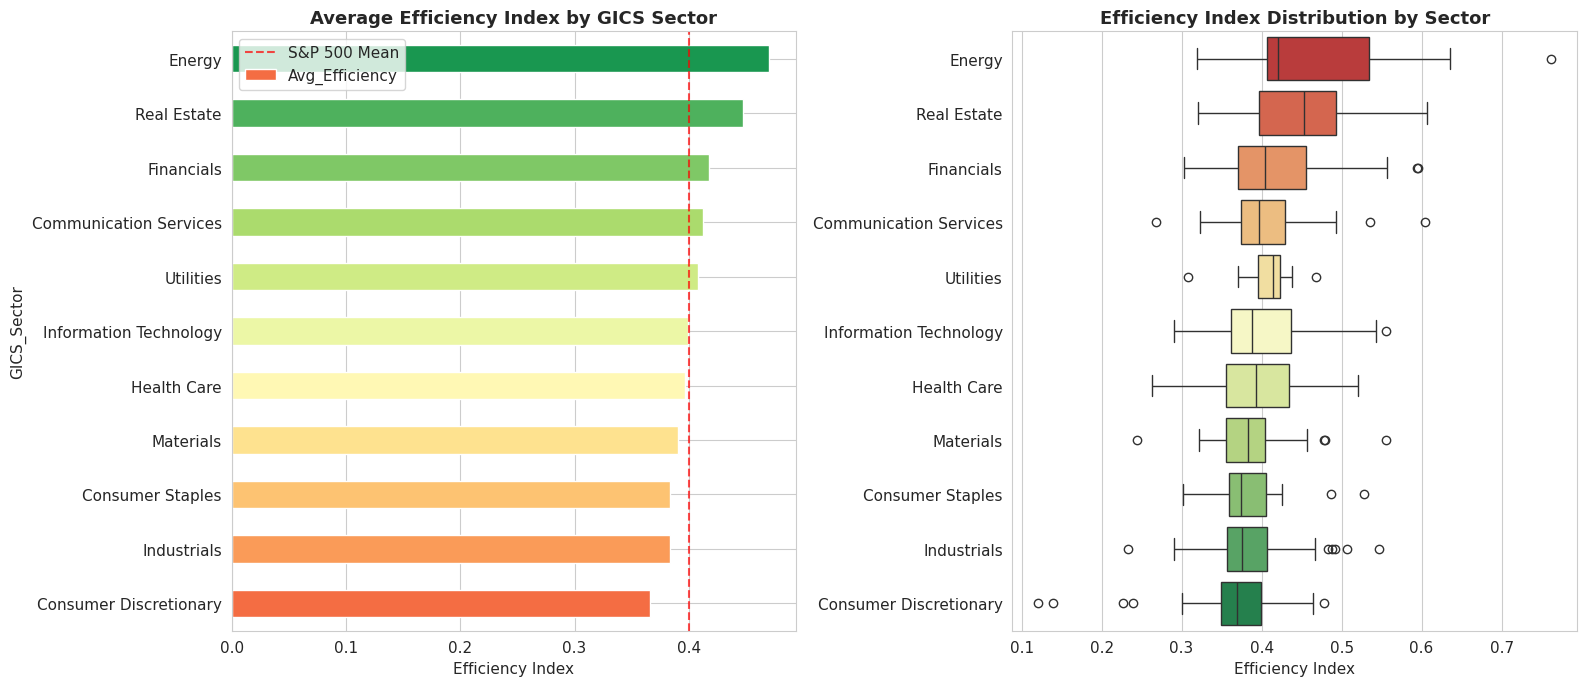

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Sector efficiency bar chart
sector_eff_sorted = sector_efficiency.sort_values('Avg_Efficiency')
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sector_eff_sorted)))
sector_eff_sorted['Avg_Efficiency'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Average Efficiency Index by GICS Sector', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Efficiency Index')
axes[0].axvline(x=df_final['Efficiency_Index'].mean(), color='red', linestyle='--', alpha=0.7, label='S&P 500 Mean')
axes[0].legend()

# Box plot showing distribution within each sector
sector_order = sector_efficiency.index.tolist()
sns.boxplot(data=df_final.dropna(subset=['Efficiency_Index']),
            x='Efficiency_Index', y='GICS_Sector', order=sector_order,
            palette='RdYlGn', ax=axes[1])
axes[1].set_title('Efficiency Index Distribution by Sector', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Efficiency Index')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 2.3 — Peer Group Analysis: Top & Bottom Performers

In [56]:
# Top 10 most efficient companies
top_10 = df_final.nlargest(10, 'Efficiency_Index')[
    ['Symbol', 'Name', 'GICS_Sector', 'Efficiency_Index',
     'Operating Margin (ttm)', 'Net Profit Margin (ttm)', 'EBITDA_to_MarketCap']
].round(4)

print('TOP 10 — Most Operationally Efficient Companies:')
print('=' * 95)
print(top_10.to_string(index=False))

# Bottom 10 least efficient companies
bottom_10 = df_final.nsmallest(10, 'Efficiency_Index')[
    ['Symbol', 'Name', 'GICS_Sector', 'Efficiency_Index',
     'Operating Margin (ttm)', 'Net Profit Margin (ttm)', 'EBITDA_to_MarketCap']
].round(4)

print(f'\nBOTTOM 10 — Least Operationally Efficient Companies:')
print('=' * 95)
print(bottom_10.to_string(index=False))

TOP 10 — Most Operationally Efficient Companies:
Symbol                 Name            GICS_Sector  Efficiency_Index  Operating Margin (ttm)  Net Profit Margin (ttm)  EBITDA_to_MarketCap
   APA      APA Corporation                 Energy              0.76                    0.56                     0.33                 0.62
  FANG   Diamondback Energy                 Energy              0.64                    0.67                     0.45                 0.14
  CTRA              Coterra                 Energy              0.62                    0.58                     0.45                 0.17
  VICI      Vici Properties            Real Estate              0.61                    0.62                     0.43                 0.12
  VRSN             Verisign Communication Services              0.60                    0.66                     0.47                 0.05
   DVN         Devon Energy                 Energy              0.60                    0.42                     0.31

### 2.4 — Growth vs. Efficiency Quadrant Matrix

Classifies each company into one of four quadrants based on their Efficiency Index and Growth Score relative to the S&P 500 median. This framework identifies which companies are converting growth into operational results and which are not.

In [57]:
# Calculate medians as thresholds
eff_median = df_final['Efficiency_Index'].median()
growth_median = df_final['Growth_Score'].median()

# Assign quadrant labels
def assign_quadrant(row):
    if pd.isna(row['Efficiency_Index']) or pd.isna(row['Growth_Score']):
        return 'Unclassified'
    if row['Efficiency_Index'] >= eff_median and row['Growth_Score'] >= growth_median:
        return 'Star'
    elif row['Efficiency_Index'] >= eff_median and row['Growth_Score'] < growth_median:
        return 'Cash Cow'
    elif row['Efficiency_Index'] < eff_median and row['Growth_Score'] >= growth_median:
        return 'Turnaround Candidate'
    else:
        return 'Underperformer'

df_final['Quadrant'] = df_final.apply(assign_quadrant, axis=1)

print('Quadrant Distribution:')
print(df_final['Quadrant'].value_counts())
print(f'\nMedian thresholds — Efficiency: {eff_median:.4f} | Growth: {growth_median:.4f}')

Quadrant Distribution:
Quadrant
Underperformer          123
Star                    121
Cash Cow                 89
Turnaround Candidate     86
Unclassified             84
Name: count, dtype: int64

Median thresholds — Efficiency: 0.3908 | Growth: 0.0704


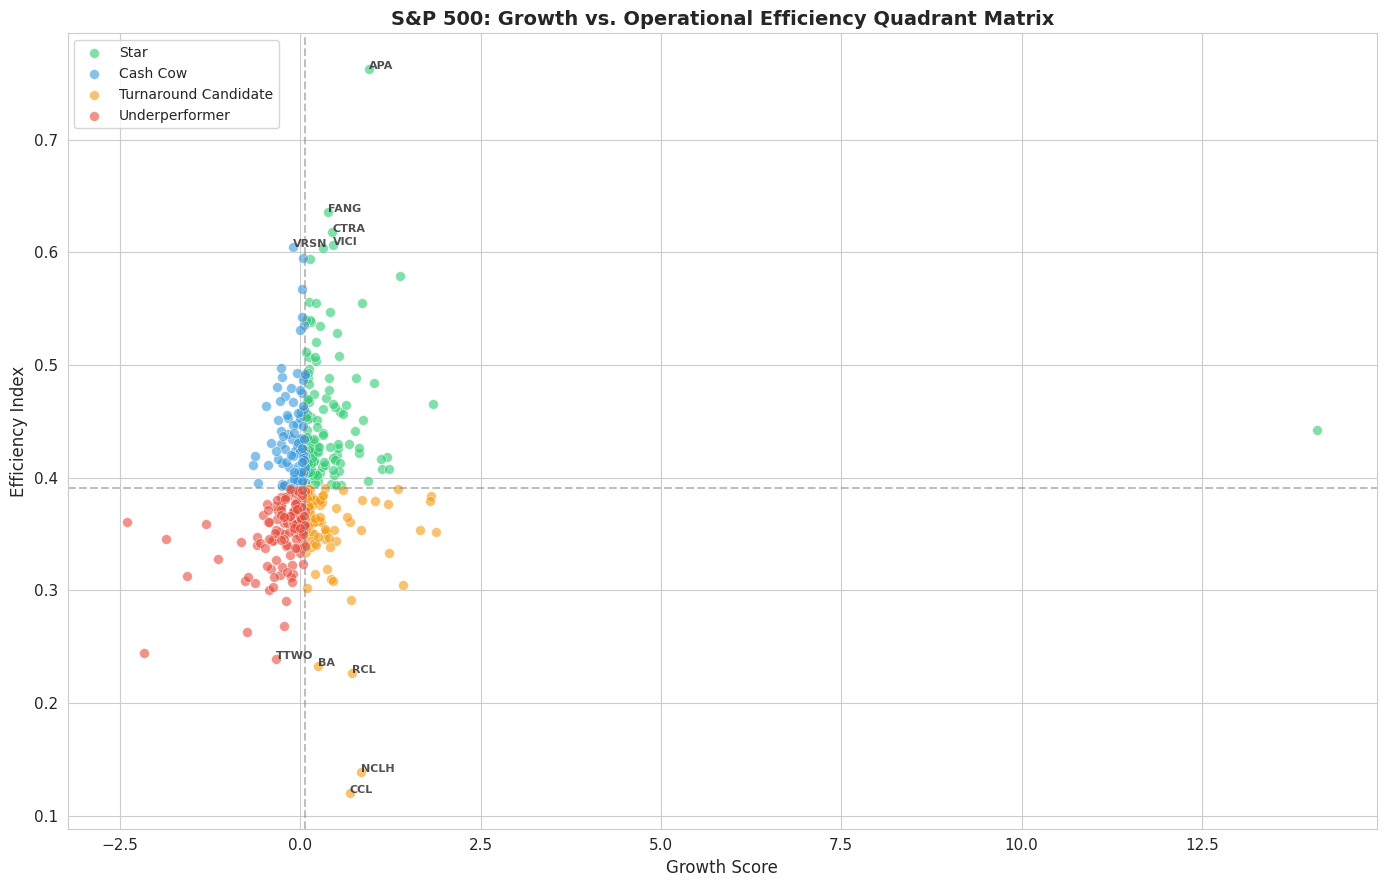

In [58]:
# Filter to classified companies only
df_plot = df_final[df_final['Quadrant'] != 'Unclassified'].copy()

quad_colors = {
    'Star': '#2ecc71',
    'Cash Cow': '#3498db',
    'Turnaround Candidate': '#f39c12',
    'Underperformer': '#e74c3c'
}

fig, ax = plt.subplots(figsize=(14, 9))

for quad, color in quad_colors.items():
    subset = df_plot[df_plot['Quadrant'] == quad]
    ax.scatter(subset['Growth_Score'], subset['Efficiency_Index'],
               c=color, label=quad, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

# Quadrant dividers
ax.axhline(y=eff_median, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=growth_median, color='gray', linestyle='--', alpha=0.5)

# Label notable companies (top 5 by efficiency)
for _, row in df_plot.nlargest(5, 'Efficiency_Index').iterrows():
    ax.annotate(row['Symbol'], (row['Growth_Score'], row['Efficiency_Index']),
                fontsize=8, fontweight='bold', alpha=0.8)

# Label bottom 5
for _, row in df_plot.nsmallest(5, 'Efficiency_Index').iterrows():
    ax.annotate(row['Symbol'], (row['Growth_Score'], row['Efficiency_Index']),
                fontsize=8, fontweight='bold', alpha=0.8)

ax.set_xlabel('Growth Score', fontsize=12)
ax.set_ylabel('Efficiency Index', fontsize=12)
ax.set_title('S&P 500: Growth vs. Operational Efficiency Quadrant Matrix', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

### 2.5 — Sector Quadrant Breakdown

Quadrant Composition by Sector:
Quadrant                Star  Cash Cow  Turnaround Candidate  Underperformer
GICS_Sector                                                                 
All                      121        89                    86             123
Information Technology    17        10                    13              17
Industrials               17         4                    25              23
Energy                    14         2                     3               2
Utilities                 14         8                     1               3
Health Care               13        15                     7              19
Consumer Discretionary    13         4                    19              14
Real Estate               11         9                     3               4
Financials                 8        15                     2              12
Consumer Staples           6         7                     5              16
Materials                  5         7      

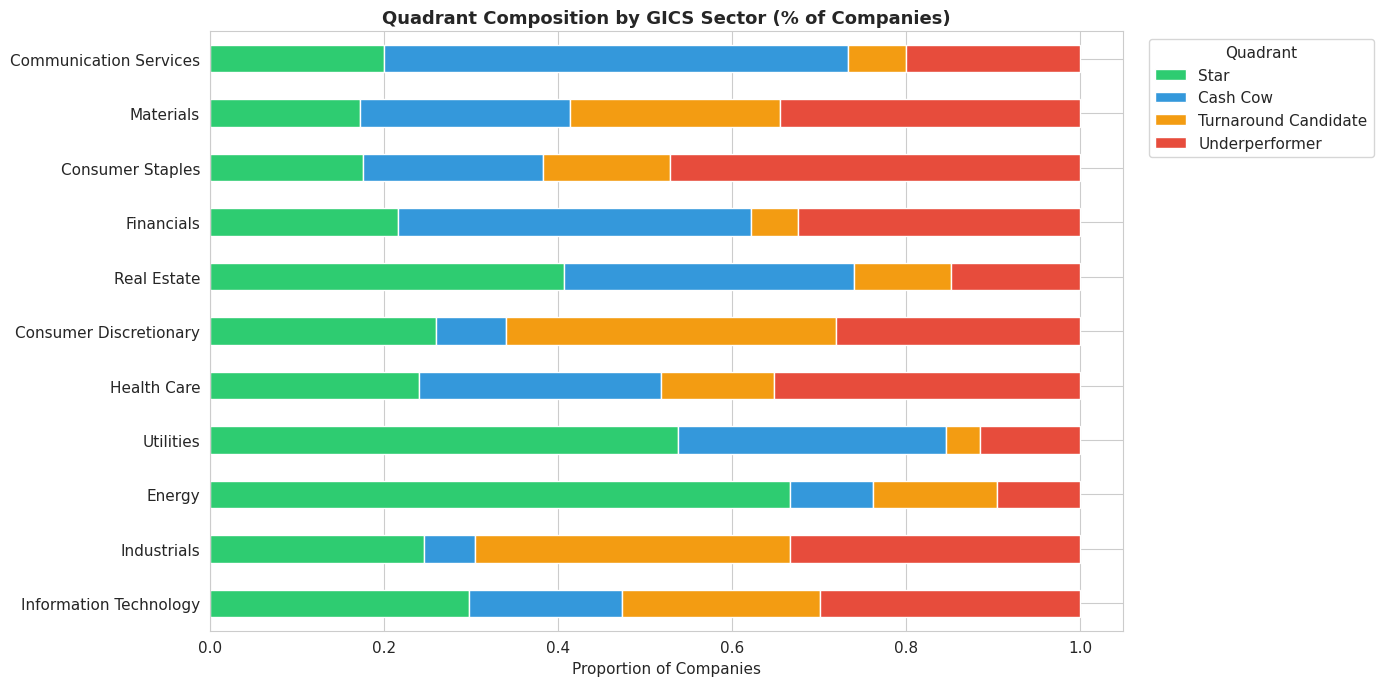

In [59]:
# Quadrant composition by sector
quadrant_by_sector = pd.crosstab(
    df_final['GICS_Sector'], df_final['Quadrant'], margins=True
)[['Star', 'Cash Cow', 'Turnaround Candidate', 'Underperformer']].sort_values('Star', ascending=False)

print('Quadrant Composition by Sector:')
print('=' * 75)
print(quadrant_by_sector)

# Visualize
quadrant_by_sector_pct = quadrant_by_sector.div(quadrant_by_sector.sum(axis=1), axis=0).drop('All', errors='ignore')

fig, ax = plt.subplots(figsize=(14, 7))
quadrant_by_sector_pct.plot(kind='barh', stacked=True, ax=ax,
                             color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'])
ax.set_title('Quadrant Composition by GICS Sector (% of Companies)', fontsize=13, fontweight='bold')
ax.set_xlabel('Proportion of Companies')
ax.set_ylabel('')
ax.legend(title='Quadrant', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 2.6 — Phase 2 Key Findings

- **Energy** leads in operational efficiency and has the highest concentration of Stars (67% of scored companies), driven by strong margins and high EBITDA relative to market cap.
- **Consumer Discretionary** ranks lowest on the Efficiency Index, with cruise lines (CCL, NCLH, RCL) pulling the sector down due to negative operating margins.
- **Industrials** has the most Turnaround Candidates (25) — companies with above-median growth but below-median efficiency, suggesting potential for margin improvement.
- **Financials** leans heavily toward Cash Cows (15) — high efficiency but lower growth, consistent with the mature nature of the sector.
- The Efficiency Index scored 419 of 503 companies (83%), with unscored companies primarily in Financials and Real Estate due to structural reporting differences.

---
## Phase 3: Financial Health Assessment & Risk Tiering

This phase builds a multi-factor Financial Health Score to segment all 503 companies into risk tiers. The model combines profitability, liquidity, and leverage indicators to assess each company's financial stability.

### 3.1 — Financial Health Score

In [60]:
# Define health score components across three dimensions

# PROFITABILITY — are they making money?
# Return on Equity, Return on Assets
# LIQUIDITY — can they cover short-term obligations?
# Current Ratio, Quick Ratio
# LEVERAGE — how much debt relative to equity?
# Total Debt to Equity (inverted — lower debt = healthier)

health_components = {
    'Profitability': ['Return on Equity (ttm)', 'Return on Assets (ttm)'],
    'Liquidity': ['Current Ratio (mrq)', 'Quick Ratio (mrq)'],
    'Leverage': ['Total Debt to Equity (mrq)']
}

# Check coverage
print('Health Score Component Coverage:')
for dimension, cols in health_components.items():
    for col in cols:
        non_null = df_final[col].notna().sum()
        print(f'  {dimension} — {col}: {non_null} / {len(df_final)} ({non_null/len(df_final)*100:.0f}%)')

Health Score Component Coverage:
  Profitability — Return on Equity (ttm): 446 / 503 (89%)
  Profitability — Return on Assets (ttm): 449 / 503 (89%)
  Liquidity — Current Ratio (mrq): 376 / 503 (75%)
  Liquidity — Quick Ratio (mrq): 375 / 503 (75%)
  Leverage — Total Debt to Equity (mrq): 423 / 503 (84%)


In [61]:
# Normalize each component to 0-1 scale using min-max
# For Debt/Equity, we invert — lower debt = higher score

def min_max_norm(series):
    return (series - series.min()) / (series.max() - series.min())

# Profitability (higher = better)
df_final['ROE_Norm'] = min_max_norm(df_final['Return on Equity (ttm)'])
df_final['ROA_Norm'] = min_max_norm(df_final['Return on Assets (ttm)'])

# Liquidity (higher = better)
df_final['Current_Ratio_Norm'] = min_max_norm(df_final['Current Ratio (mrq)'])
df_final['Quick_Ratio_Norm'] = min_max_norm(df_final['Quick Ratio (mrq)'])

# Leverage (lower = better, so we invert)
df_final['Debt_Equity_Norm'] = 1 - min_max_norm(df_final['Total Debt to Equity (mrq)'])

# Weighted composite: Profitability 40%, Liquidity 30%, Leverage 30%
df_final['Profitability_Health'] = (df_final['ROE_Norm'] + df_final['ROA_Norm']) / 2
df_final['Liquidity_Health'] = (df_final['Current_Ratio_Norm'] + df_final['Quick_Ratio_Norm']) / 2
df_final['Leverage_Health'] = df_final['Debt_Equity_Norm']

df_final['Health_Score'] = (
    df_final['Profitability_Health'] * 0.40 +
    df_final['Liquidity_Health'] * 0.30 +
    df_final['Leverage_Health'] * 0.30
)

coverage = df_final['Health_Score'].notna().sum()
print(f'Health Score built: {coverage} / {len(df_final)} companies scored ({coverage/len(df_final)*100:.0f}%)')
print(f'\nDistribution:')
print(df_final['Health_Score'].describe().round(4))

Health Score built: 342 / 503 companies scored (68%)

Distribution:
count   342.00
mean      0.57
std       0.07
min       0.10
25%       0.53
50%       0.55
75%       0.59
max       0.84
Name: Health_Score, dtype: float64


### 3.2 — Risk Tier Classification

In [62]:
# Segment companies into risk tiers based on Health Score percentiles
def assign_risk_tier(score):
    if pd.isna(score):
        return 'Unscored'
    elif score >= df_final['Health_Score'].quantile(0.75):
        return 'Strong'
    elif score >= df_final['Health_Score'].quantile(0.50):
        return 'Stable'
    elif score >= df_final['Health_Score'].quantile(0.25):
        return 'Watch'
    else:
        return 'Distressed'

df_final['Risk_Tier'] = df_final['Health_Score'].apply(assign_risk_tier)

print('Risk Tier Distribution:')
print('=' * 50)
print(df_final['Risk_Tier'].value_counts())

# Average metrics by tier
tier_summary = df_final.groupby('Risk_Tier').agg(
    Avg_Health_Score=('Health_Score', 'mean'),
    Avg_ROE=('Return on Equity (ttm)', 'mean'),
    Avg_Current_Ratio=('Current Ratio (mrq)', 'mean'),
    Avg_Debt_Equity=('Total Debt to Equity (mrq)', 'mean'),
    Company_Count=('Health_Score', 'count')
).round(4)

tier_order = ['Strong', 'Stable', 'Watch', 'Distressed', 'Unscored']
tier_summary = tier_summary.reindex(tier_order)
print(f'\nTier Profile Summary:')
print('=' * 80)
print(tier_summary)

Risk Tier Distribution:
Risk_Tier
Unscored      161
Strong         86
Distressed     86
Stable         85
Watch          85
Name: count, dtype: int64

Tier Profile Summary:
            Avg_Health_Score  Avg_ROE  Avg_Current_Ratio  Avg_Debt_Equity  \
Risk_Tier                                                                   
Strong                  0.66     0.54               2.62             0.78   
Stable                  0.57     0.32               1.59             1.15   
Watch                   0.54     0.28               1.18             1.33   
Distressed              0.50     0.02               0.80             5.25   
Unscored                 NaN    -0.15               1.17             3.10   

            Company_Count  
Risk_Tier                  
Strong                 86  
Stable                 85  
Watch                  85  
Distressed             86  
Unscored                0  


### 3.3 — Risk Tier Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Risk tier by sector
tier_by_sector = pd.crosstab(df_final['GICS_Sector'], df_final['Risk_Tier'])
tier_by_sector = tier_by_sector[['Strong', 'Stable', 'Watch', 'Distressed']].sort_values('Strong', ascending=True)

tier_colors = {'Strong': '#2ecc71', 'Stable': '#3498db', 'Watch': '#f39c12', 'Distressed': '#e74c3c'}
tier_by_sector.plot(kind='barh', stacked=True, ax=axes[0],
                     color=[tier_colors[c] for c in tier_by_sector.columns])
axes[0].set_title('Risk Tier Distribution by Sector', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Companies')
axes[0].set_ylabel('')
axes[0].legend(title='Risk Tier', bbox_to_anchor=(1.02, 1), loc='upper left')

# Health Score distribution by tier
tier_order = ['Strong', 'Stable', 'Watch', 'Distressed']
df_scored = df_final[df_final['Risk_Tier'] != 'Unscored']
sns.boxplot(data=df_scored, x='Health_Score', y='Risk_Tier', order=tier_order,
            palette=[tier_colors[t] for t in tier_order], ax=axes[1])
axes[1].set_title('Health Score Distribution by Risk Tier', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Health Score')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 3.4 — Dividend Sustainability Check

In [63]:
# Flag companies where dividend payout ratio exceeds earnings capacity
df_dividends = df_final[df_final['Dividend Payout Ratio (ttm)'].notna()].copy()

df_dividends['Dividend_Flag'] = np.where(
    df_dividends['Dividend Payout Ratio (ttm)'] > 1.0, 'Unsustainable (>100%)',
    np.where(df_dividends['Dividend Payout Ratio (ttm)'] > 0.75, 'Elevated (75-100%)',
    np.where(df_dividends['Dividend Payout Ratio (ttm)'] > 0, 'Sustainable (<75%)', 'No Dividend')))

print(f'Dividend Sustainability Analysis ({len(df_dividends)} companies with payout data):')
print('=' * 60)
print(df_dividends['Dividend_Flag'].value_counts())

# Show the companies with unsustainable payouts
unsustainable = df_dividends[df_dividends['Dividend_Flag'] == 'Unsustainable (>100%)'][
    ['Symbol', 'Name', 'GICS_Sector', 'Dividend Payout Ratio (ttm)', 'Risk_Tier']
].sort_values('Dividend Payout Ratio (ttm)', ascending=False).round(4)

print(f'\nCompanies with Payout Ratio > 100%:')
print('=' * 80)
print(unsustainable.to_string(index=False))

Dividend Sustainability Analysis (430 companies with payout data):
Dividend_Flag
Sustainable (<75%)       294
No Dividend               80
Unsustainable (>100%)     29
Elevated (75-100%)        27
Name: count, dtype: int64

Companies with Payout Ratio > 100%:
Symbol                            Name            GICS_Sector  Dividend Payout Ratio (ttm)  Risk_Tier
   STZ            Constellation Brands       Consumer Staples                         6.10 Distressed
   UDR                       UDR, Inc.            Real Estate                         5.90   Unscored
   KIM                    Kimco Realty            Real Estate                         4.87   Unscored
   DLR                  Digital Realty            Real Estate                         4.09   Unscored
   IBM                             IBM Information Technology                         3.63 Distressed
  WELL                       Welltower            Real Estate                         2.75   Unscored
     D                 Dom

### 3.5 — Phase 3 Key Findings

- **342 companies scored** across the Health Score model (68% coverage). Unscored companies are primarily Financials and REITs where liquidity ratios are not reported.
- **Strong tier** companies average 0.78 debt-to-equity vs. 5.25 for Distressed — a clear separation in leverage risk.
- **Information Technology** has the highest concentration of Strong-tier companies, reflecting the sector's low capital intensity and high margins.
- **29 companies flagged for unsustainable dividends** (payout ratio >100%). The majority are REITs, where this is expected — REITs are required to distribute 90%+ of taxable income by law. Non-REIT flags like IBM, Constellation Brands, and Clorox warrant closer examination.
- **Utilities** appear frequently in both Distressed and unsustainable dividend lists, driven by high debt loads typical of capital-intensive regulated industries rather than operational failure.

---
## Phase 4: Valuation Gap Analysis

This phase compares market valuation against fundamental performance to identify disconnects — companies the market may be overpricing or underpricing relative to their operational efficiency and financial health.

### 4.1 — Valuation vs. Fundamentals

In [65]:
# Build a Fundamental Score combining Efficiency Index and Health Score
# This represents how well a company actually performs operationally and financially
df_final['Fundamental_Score'] = df_final[['Efficiency_Index', 'Health_Score']].mean(axis=1)

# Valuation Composite Z-score already built in Phase 1
# Higher Z = more expensive relative to peers
# Compare: are expensive stocks actually better performers?

df_gap = df_final[
    df_final['Fundamental_Score'].notna() & df_final['Valuation_Composite_Z'].notna()
].copy()

# Normalize both to 0-1 for direct comparison
df_gap['Fund_Norm'] = (df_gap['Fundamental_Score'] - df_gap['Fundamental_Score'].min()) / \
                       (df_gap['Fundamental_Score'].max() - df_gap['Fundamental_Score'].min())

df_gap['Val_Norm'] = (df_gap['Valuation_Composite_Z'] - df_gap['Valuation_Composite_Z'].min()) / \
                      (df_gap['Valuation_Composite_Z'].max() - df_gap['Valuation_Composite_Z'].min())

# Valuation Gap = Normalized Valuation - Normalized Fundamentals
# Positive = potentially overvalued (priced higher than fundamentals justify)
# Negative = potentially undervalued (priced lower than fundamentals suggest)
df_gap['Valuation_Gap'] = df_gap['Val_Norm'] - df_gap['Fund_Norm']

# Merge back to main dataframe
df_final = df_final.merge(
    df_gap[['Symbol', 'Fundamental_Score', 'Fund_Norm', 'Val_Norm', 'Valuation_Gap']],
    on='Symbol', how='left', suffixes=('', '_dup')
)

# Clean up any duplicate columns
dup_cols = [c for c in df_final.columns if c.endswith('_dup')]
df_final = df_final.drop(columns=dup_cols)

coverage = df_final['Valuation_Gap'].notna().sum()
print(f'Valuation Gap scored: {coverage} / {len(df_final)} companies ({coverage/len(df_final)*100:.0f}%)')
print(f'\nDistribution:')
print(df_final['Valuation_Gap'].describe().round(4))

Valuation Gap scored: 421 / 503 companies (84%)

Distribution:
count   421.00
mean     -0.47
std       0.14
min      -0.98
25%      -0.54
50%      -0.49
75%      -0.42
max       0.48
Name: Valuation_Gap, dtype: float64


### 4.2 — Valuation Disconnects

In [66]:
gap_cols = ['Symbol', 'Name', 'GICS_Sector', 'Valuation_Gap',
            'Valuation_Composite_Z', 'Efficiency_Index', 'Health_Score']

# Top 10 potentially overvalued (market prices high, fundamentals don't justify)
overvalued = df_final.nlargest(10, 'Valuation_Gap')[gap_cols].round(4)
print('TOP 10 — Potentially Overvalued (highest valuation gap):')
print('=' * 95)
print(overvalued.to_string(index=False))

# Top 10 potentially undervalued (strong fundamentals, low market valuation)
undervalued = df_final.nsmallest(10, 'Valuation_Gap')[gap_cols].round(4)
print(f'\nTOP 10 — Potentially Undervalued (lowest valuation gap):')
print('=' * 95)
print(undervalued.to_string(index=False))

TOP 10 — Potentially Overvalued (highest valuation gap):
Symbol                           Name            GICS_Sector  Valuation_Gap  Valuation_Composite_Z  Efficiency_Index  Health_Score
   CLX                         Clorox       Consumer Staples           0.48                   4.92              0.34          0.52
  GILD                Gilead Sciences            Health Care           0.28                   4.39              0.44          0.56
   LYV      Live Nation Entertainment Consumer Discretionary           0.16                   1.99              0.31           NaN
  NCLH Norwegian Cruise Line Holdings Consumer Discretionary           0.07                  -0.24              0.14          0.10
  INCY                         Incyte            Health Care           0.03                   3.22              0.35          0.68
  FTNT                       Fortinet Information Technology          -0.02                   1.79              0.39           NaN
    CL              Colgat

### 4.3 — Valuation Gap Visualization

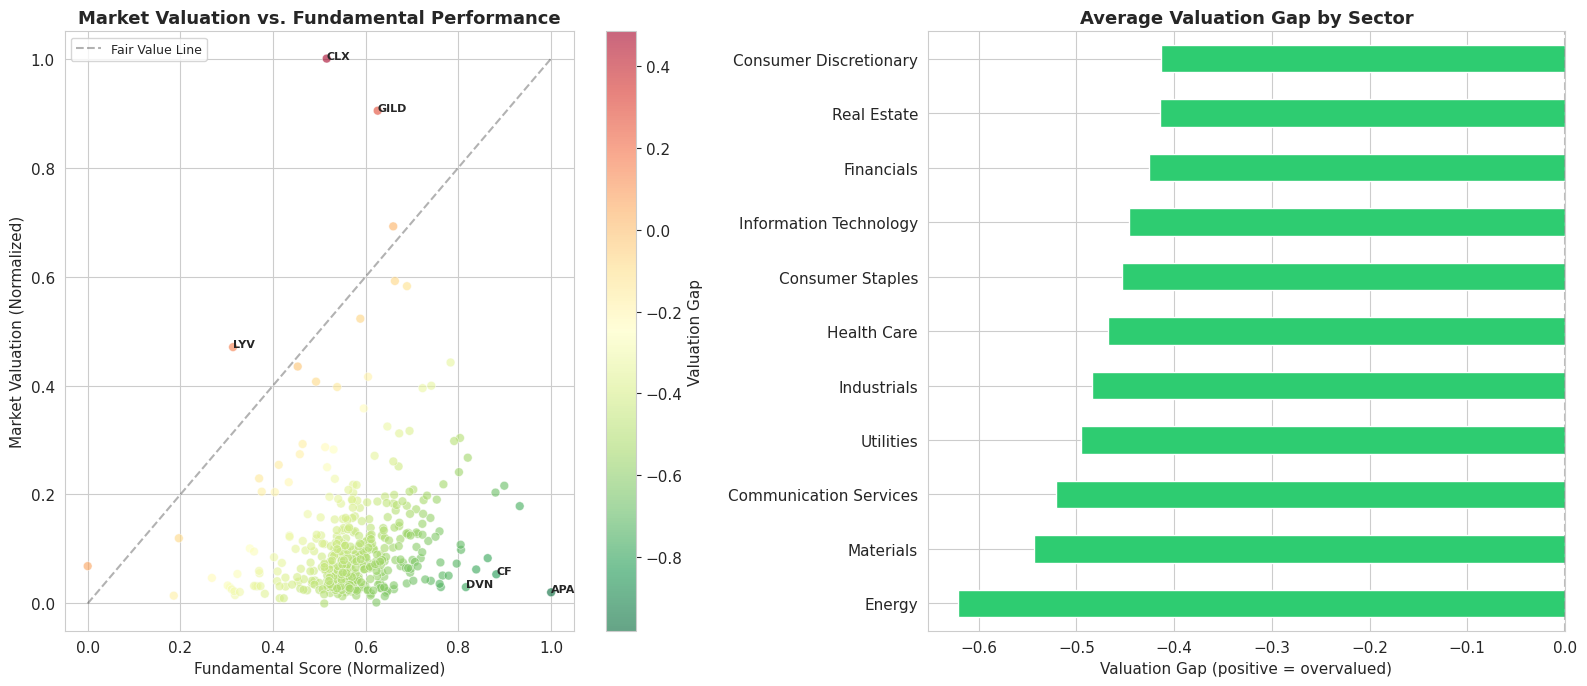

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter: Fundamental Score vs. Valuation
df_scatter = df_final[df_final['Valuation_Gap'].notna()].copy()
scatter = axes[0].scatter(df_scatter['Fund_Norm'], df_scatter['Val_Norm'],
                          c=df_scatter['Valuation_Gap'], cmap='RdYlGn_r',
                          alpha=0.6, s=40, edgecolors='white', linewidth=0.5)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Fair Value Line')
plt.colorbar(scatter, ax=axes[0], label='Valuation Gap')

# Label extreme overvalued
for _, row in df_scatter.nlargest(3, 'Valuation_Gap').iterrows():
    axes[0].annotate(row['Symbol'], (row['Fund_Norm'], row['Val_Norm']),
                     fontsize=8, fontweight='bold')
# Label extreme undervalued
for _, row in df_scatter.nsmallest(3, 'Valuation_Gap').iterrows():
    axes[0].annotate(row['Symbol'], (row['Fund_Norm'], row['Val_Norm']),
                     fontsize=8, fontweight='bold')

axes[0].set_xlabel('Fundamental Score (Normalized)', fontsize=11)
axes[0].set_ylabel('Market Valuation (Normalized)', fontsize=11)
axes[0].set_title('Market Valuation vs. Fundamental Performance', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

# Sector average valuation gap
sector_gap = df_final.groupby('GICS_Sector')['Valuation_Gap'].mean().sort_values()
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in sector_gap.values]
sector_gap.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Average Valuation Gap by Sector', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Valuation Gap (positive = overvalued)')
axes[1].set_ylabel('')
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 4.4 — Phase 4 Key Findings

- **421 companies scored** on the Valuation Gap metric (84% coverage).
- **Clorox (CLX)** shows the largest overvaluation gap — high market multiples paired with below-average efficiency (0.34) and a weak health score (0.52).
- **APA Corporation** shows the largest undervaluation gap — the highest Efficiency Index in the dataset (0.76) with a strong Health Score (0.69), yet the market prices it at a discount.
- **Energy** is the most undervalued sector on average, consistent with strong operational fundamentals but historically low market multiples.
- **Consumer Discretionary** sits closest to fair value as a sector, though individual companies like Norwegian Cruise Line (NCLH) still show overvaluation relative to their weak fundamentals.
- The undervalued list is dominated by Energy and Materials — capital-intensive sectors where the market tends to discount cyclical earnings despite current operational strength.

---
## Phase 5: Executive Dashboard & Strategic Insights

Final phase consolidates all scoring models into a unified sector-level view and surfaces the top strategic takeaways from the analysis.

### 5.1 — Sector Performance Heatmap

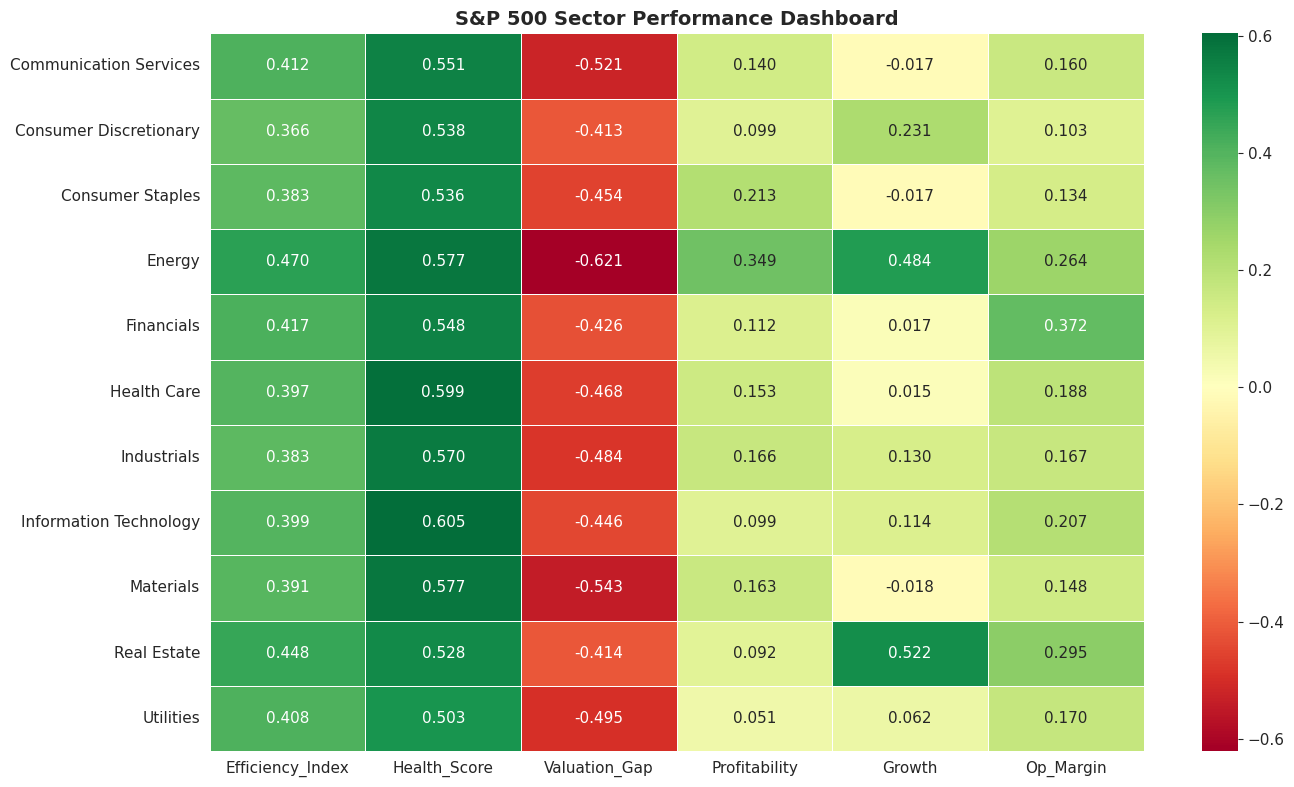


Full Sector Dashboard:
                        Efficiency_Index  Health_Score  Valuation_Gap  \
GICS_Sector                                                             
Communication Services              0.41          0.55          -0.52   
Consumer Discretionary              0.37          0.54          -0.41   
Consumer Staples                    0.38          0.54          -0.45   
Energy                              0.47          0.58          -0.62   
Financials                          0.42          0.55          -0.43   
Health Care                         0.40          0.60          -0.47   
Industrials                         0.38          0.57          -0.48   
Information Technology              0.40          0.60          -0.45   
Materials                           0.39          0.58          -0.54   
Real Estate                         0.45          0.53          -0.41   
Utilities                           0.41          0.50          -0.49   

                        Pr

In [68]:
# Consolidated sector-level metrics
sector_dashboard = df_final.groupby('GICS_Sector').agg(
    Efficiency_Index=('Efficiency_Index', 'mean'),
    Health_Score=('Health_Score', 'mean'),
    Valuation_Gap=('Valuation_Gap', 'mean'),
    Profitability=('Profitability_Score', 'mean'),
    Growth=('Growth_Score', 'mean'),
    Op_Margin=('Operating Margin (ttm)', 'mean'),
    Debt_to_Equity=('Total Debt to Equity (mrq)', 'mean'),
    Company_Count=('Symbol', 'count')
).round(4)

# Heatmap of key metrics
heat_cols = ['Efficiency_Index', 'Health_Score', 'Valuation_Gap', 'Profitability', 'Growth', 'Op_Margin']
heat_data = sector_dashboard[heat_cols].copy()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('S&P 500 Sector Performance Dashboard', fontsize=14, fontweight='bold')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

print('\nFull Sector Dashboard:')
print('=' * 100)
print(sector_dashboard)

### 5.2 — Top Companies: Combined Scorecard

In [69]:
# Companies that rank well across ALL three scoring models
df_scored = df_final[
    df_final['Efficiency_Index'].notna() &
    df_final['Health_Score'].notna() &
    df_final['Valuation_Gap'].notna()
].copy()

# Combined rank — average percentile across all three scores
df_scored['Eff_Rank'] = df_scored['Efficiency_Index'].rank(pct=True)
df_scored['Health_Rank'] = df_scored['Health_Score'].rank(pct=True)
df_scored['Value_Rank'] = (df_scored['Valuation_Gap'] * -1).rank(pct=True)  # Invert — more undervalued = better

df_scored['Combined_Rank'] = (df_scored['Eff_Rank'] + df_scored['Health_Rank'] + df_scored['Value_Rank']) / 3

# Top 15 overall
top_overall = df_scored.nlargest(15, 'Combined_Rank')[
    ['Symbol', 'Name', 'GICS_Sector', 'Efficiency_Index', 'Health_Score',
     'Valuation_Gap', 'Combined_Rank', 'Quadrant', 'Risk_Tier']
].round(4)

print('TOP 15 — Highest Combined Score (Efficiency + Health + Value):')
print('=' * 110)
print(top_overall.to_string(index=False))

TOP 15 — Highest Combined Score (Efficiency + Health + Value):
Symbol                      Name            GICS_Sector  Efficiency_Index  Health_Score  Valuation_Gap  Combined_Rank Quadrant Risk_Tier
    CF             CF Industries              Materials              0.56          0.75          -0.83           0.99     Star    Strong
   TXN         Texas Instruments Information Technology              0.54          0.83          -0.75           0.98 Cash Cow    Strong
   APA           APA Corporation                 Energy              0.76          0.69          -0.98           0.98     Star    Strong
  REGN Regeneron Pharmaceuticals            Health Care              0.50          0.79          -0.78           0.98 Cash Cow    Strong
  VRTX    Vertex Pharmaceuticals            Health Care              0.52          0.81          -0.68           0.97     Star    Strong
  CPRT                    Copart            Industrials              0.47          0.84          -0.68           0.

### 5.3 — Strategic Quadrant Summary

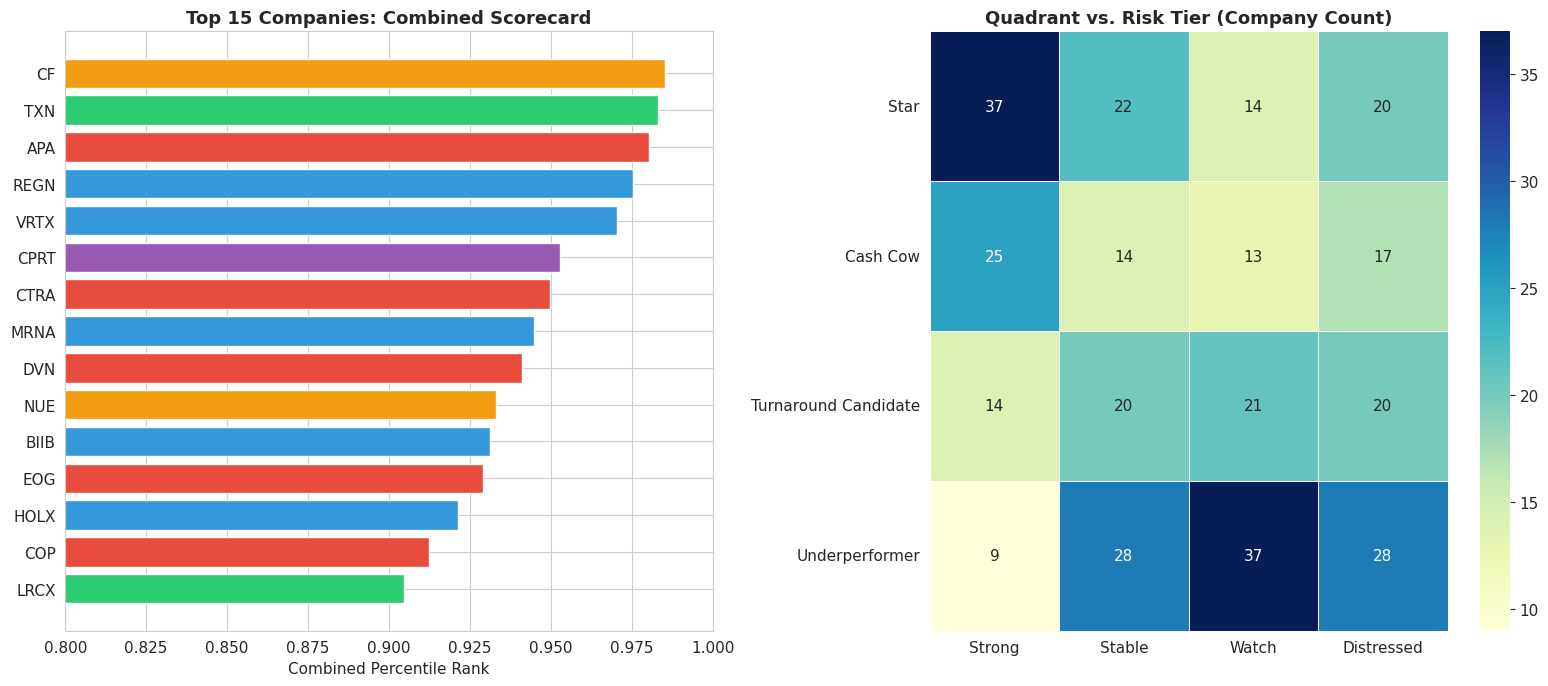

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15 combined score horizontal bar
top_15 = df_scored.nlargest(15, 'Combined_Rank')[['Symbol', 'Combined_Rank', 'GICS_Sector']].copy()
sector_colors = {
    'Energy': '#e74c3c', 'Health Care': '#3498db', 'Information Technology': '#2ecc71',
    'Materials': '#f39c12', 'Industrials': '#9b59b6', 'Financials': '#1abc9c',
    'Consumer Discretionary': '#e67e22', 'Consumer Staples': '#34495e',
    'Utilities': '#7f8c8d', 'Real Estate': '#c0392b', 'Communication Services': '#2980b9'
}
bar_colors = [sector_colors.get(s, '#95a5a6') for s in top_15['GICS_Sector']]

axes[0].barh(top_15['Symbol'][::-1], top_15['Combined_Rank'][::-1], color=bar_colors[::-1])
axes[0].set_title('Top 15 Companies: Combined Scorecard', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Combined Percentile Rank')
axes[0].set_xlim(0.8, 1.0)

# Quadrant vs Risk Tier crosstab
scored_only = df_final[df_final['Risk_Tier'] != 'Unscored']
cross = pd.crosstab(scored_only['Quadrant'], scored_only['Risk_Tier'])
cross = cross.reindex(columns=['Strong', 'Stable', 'Watch', 'Distressed'])
cross = cross.reindex(['Star', 'Cash Cow', 'Turnaround Candidate', 'Underperformer'])

sns.heatmap(cross, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1], linewidths=0.5)
axes[1].set_title('Quadrant vs. Risk Tier (Company Count)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### 5.4 — Phase 5 Key Findings

- **CF Industries, Texas Instruments, and APA Corporation** rank as the top three companies across all scoring dimensions — strong operations, healthy balance sheets, and undervalued by the market.
- **Energy and Health Care** dominate the top 15 combined scorecard, contributing 5 and 5 companies respectively.
- **Every company in the top 15 is Strong-tier**, confirming that the scoring models align — operationally efficient companies with healthy financials also tend to be undervalued.
- **Stars + Strong** is the most desirable classification. Companies in this intersection represent the highest combined operational and financial quality with above-median growth.
- **Underperformer + Distressed** is the highest-risk intersection — companies with weak efficiency, poor financial health, and below-median growth.

---
### 5.5 — Final Dataset Export

In [71]:
# Export the fully enriched dataset with all scores and classifications
df_final.to_csv('sp500_master_dataset_final.csv', index=False)

print(f'=== ANALYSIS COMPLETE ===')
print(f'\nExported: sp500_master_dataset_final.csv')
print(f'  Companies:       {df_final.shape[0]}')
print(f'  Total features:  {df_final.shape[1]}')
print(f'  Scored models:   Efficiency Index, Health Score, Valuation Gap')
print(f'  Classifications: Quadrant (4), Risk Tier (4)')

=== ANALYSIS COMPLETE ===

Exported: sp500_master_dataset_final.csv
  Companies:       503
  Total features:  106
  Scored models:   Efficiency Index, Health Score, Valuation Gap
  Classifications: Quadrant (4), Risk Tier (4)


---
## Deliverable 2: Visualization Suite Export

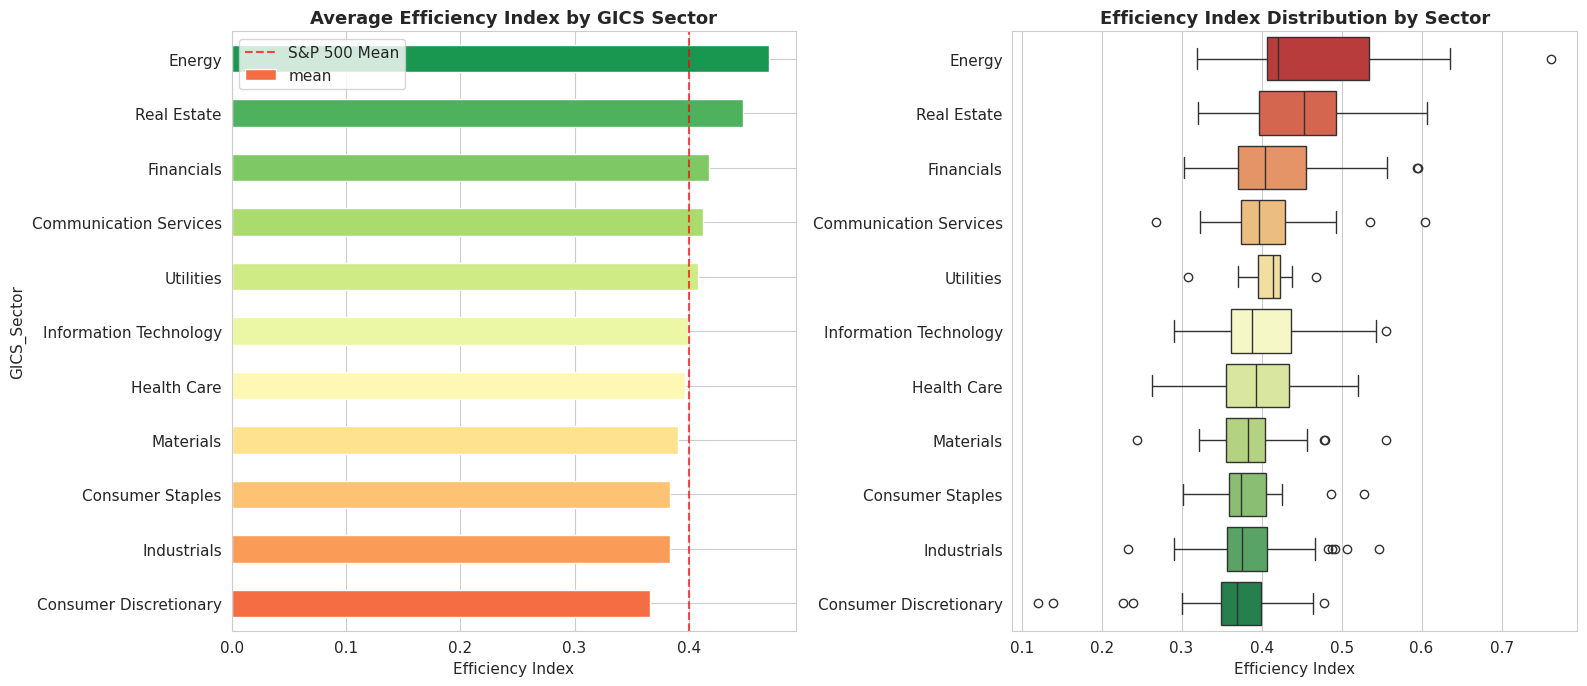

Saved: 01_sector_efficiency.png


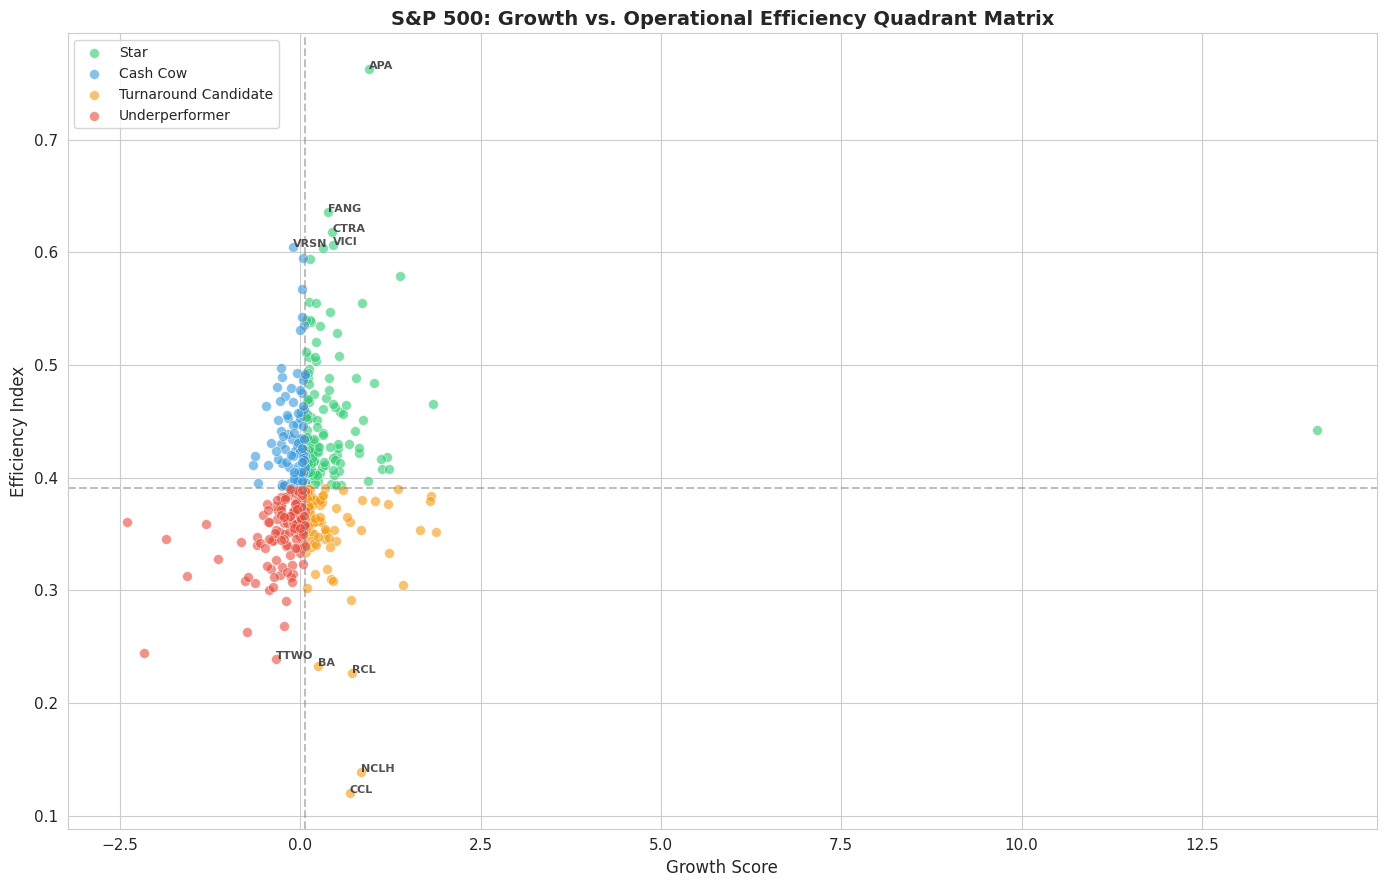

Saved: 02_quadrant_matrix.png


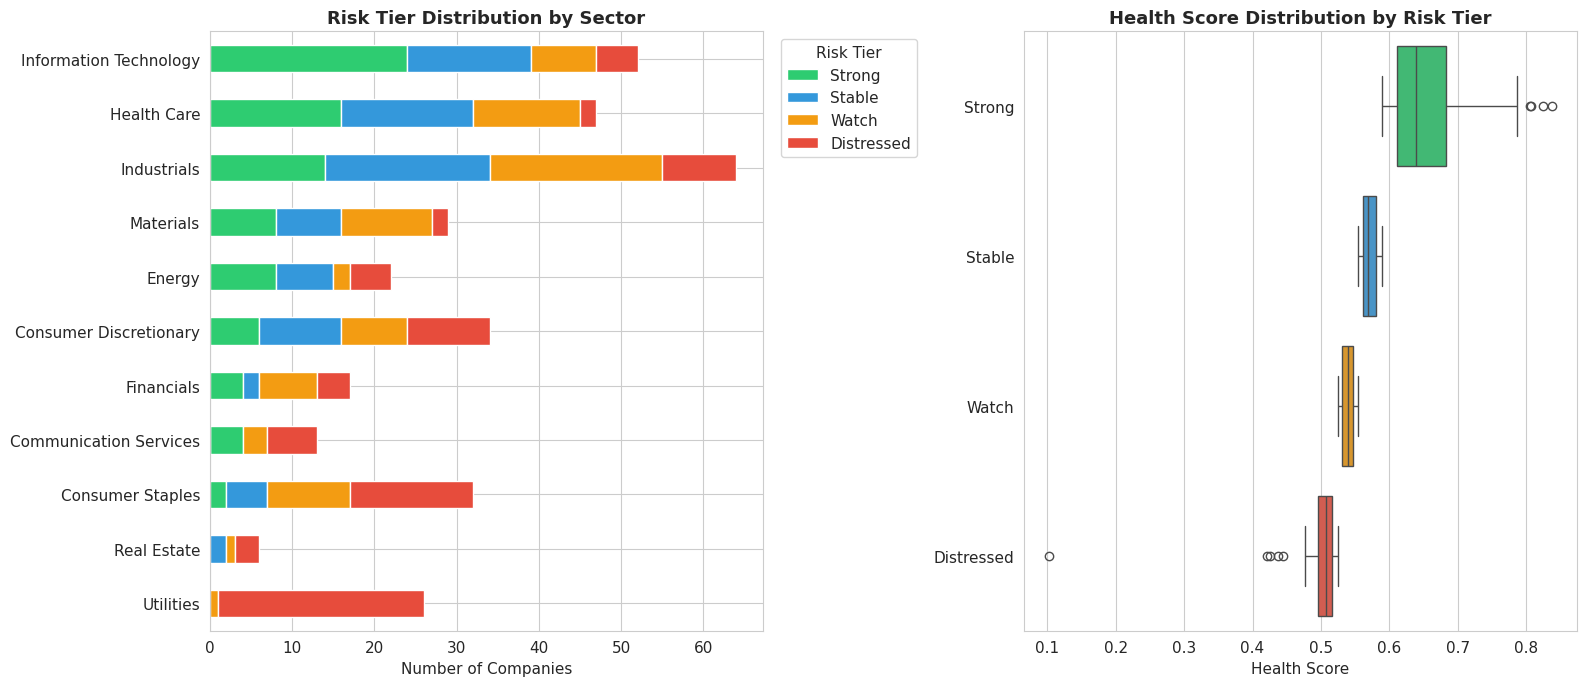

Saved: 03_risk_tiers.png


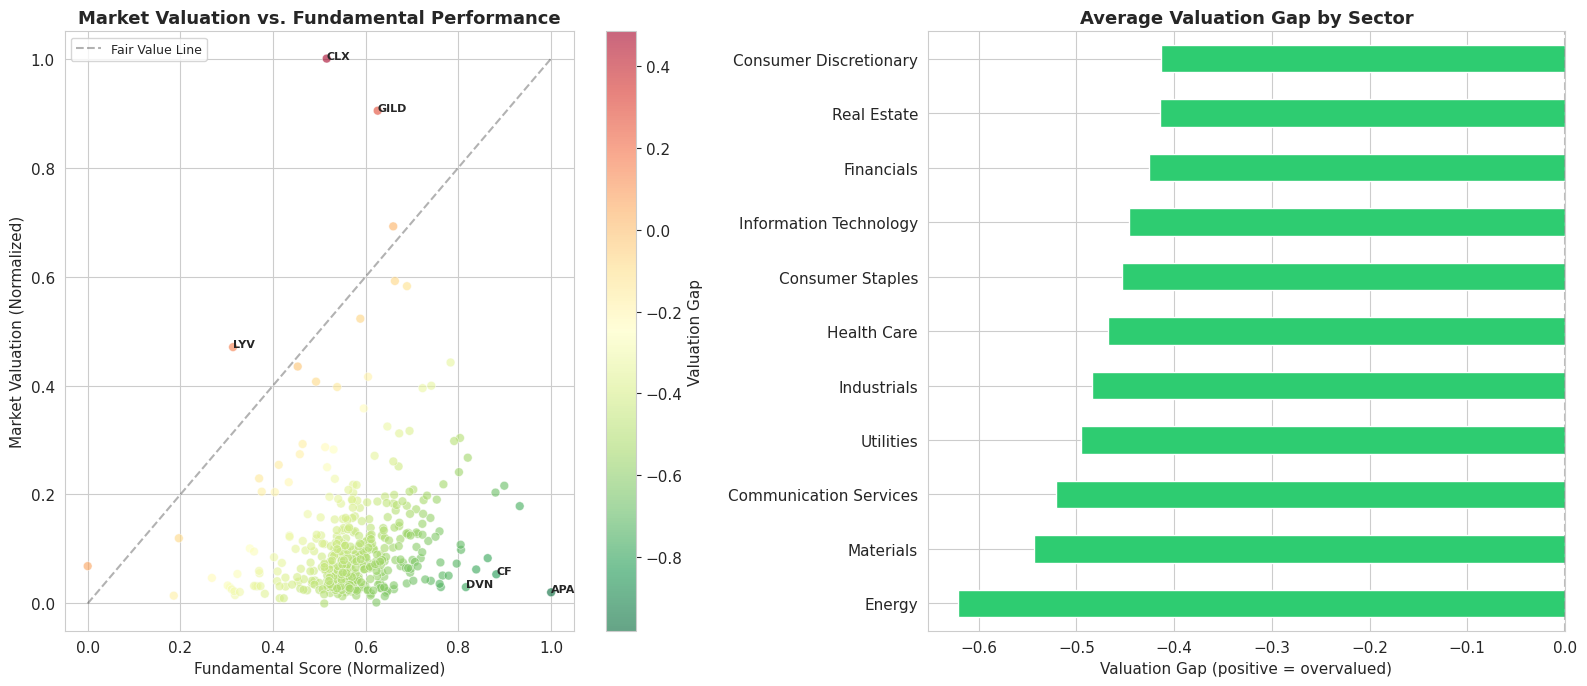

Saved: 04_valuation_gap.png


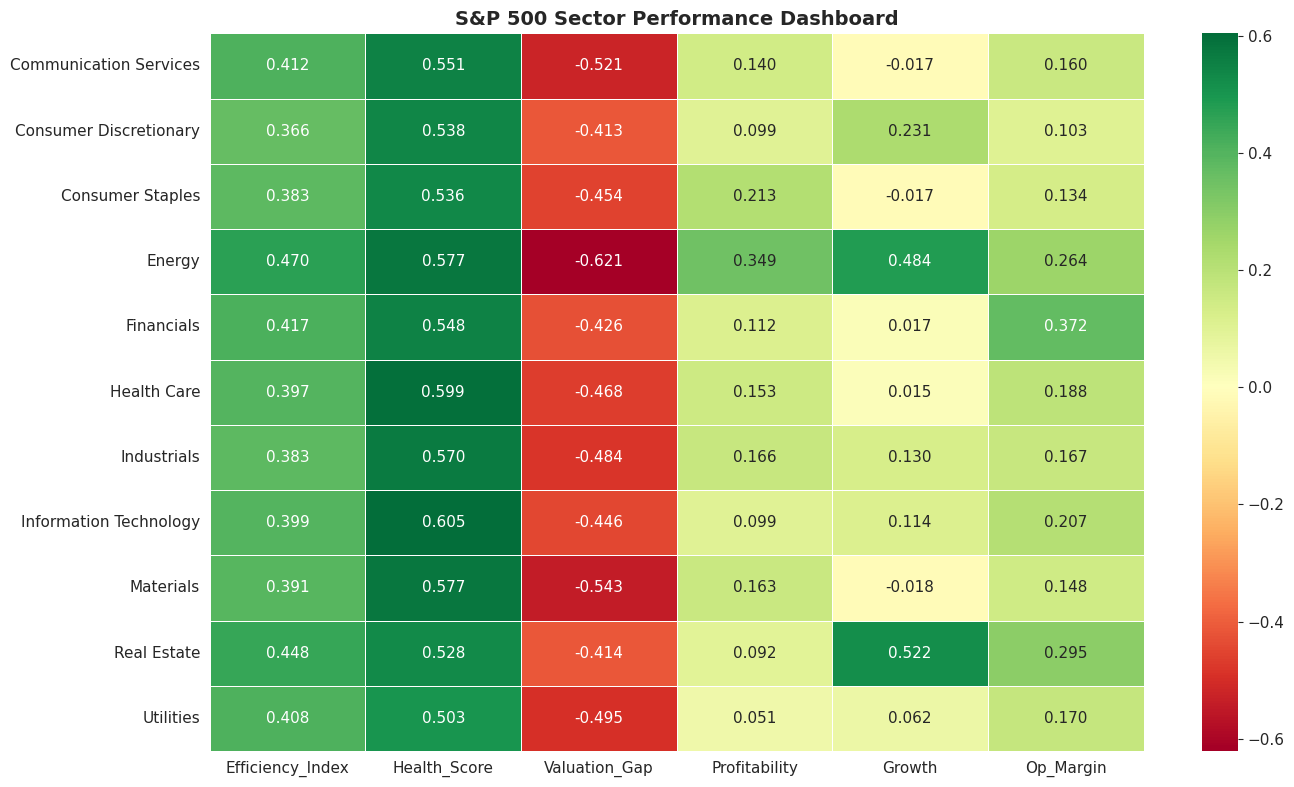

Saved: 05_sector_dashboard.png


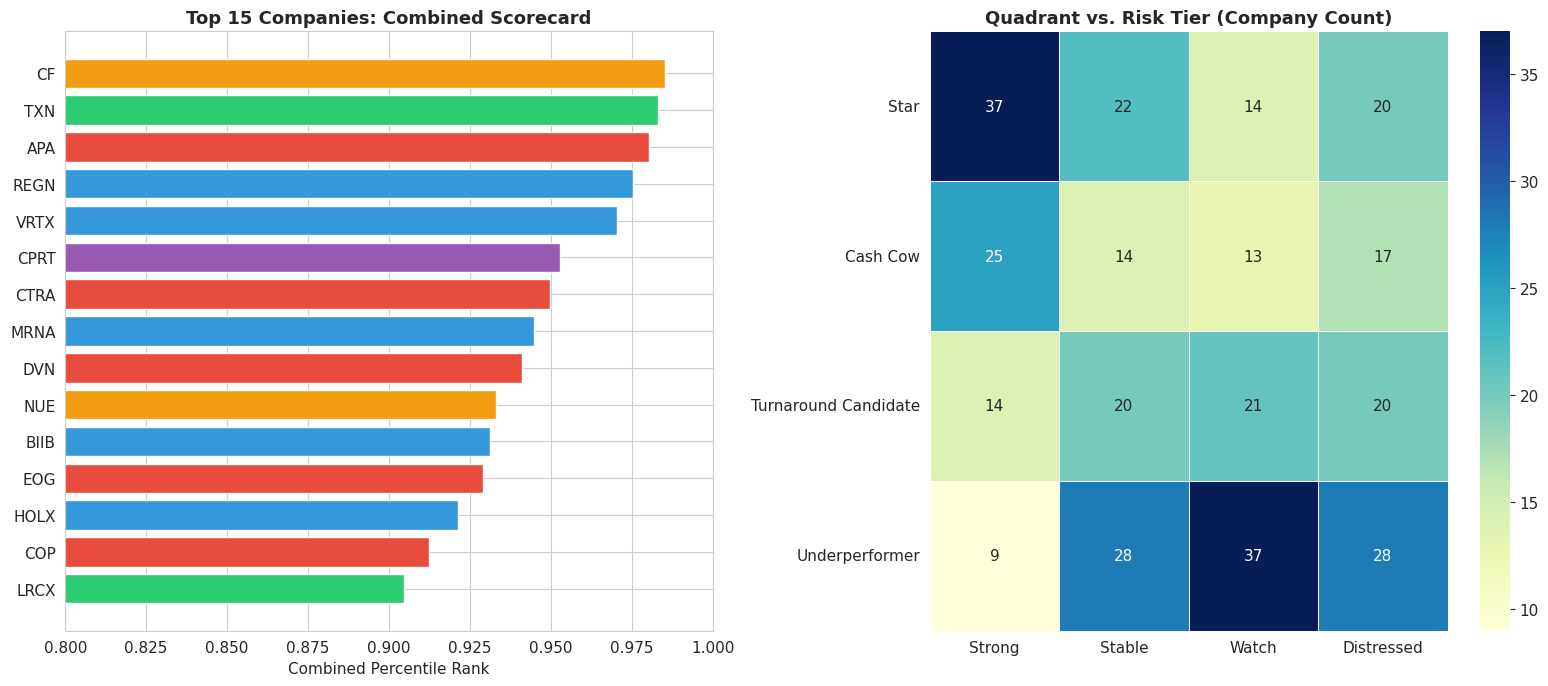

Saved: 06_combined_scorecard.png

=== ALL VISUALIZATIONS EXPORTED ===


In [72]:
import os
os.makedirs('visualizations', exist_ok=True)

# Chart 1 — Sector Efficiency Rankings
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sector_efficiency = df_final.groupby('GICS_Sector')['Efficiency_Index'].agg(['mean', 'median', 'count']).sort_values('mean')
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sector_efficiency)))
sector_efficiency['mean'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Average Efficiency Index by GICS Sector', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Efficiency Index')
axes[0].axvline(x=df_final['Efficiency_Index'].mean(), color='red', linestyle='--', alpha=0.7, label='S&P 500 Mean')
axes[0].legend()
sector_order = sector_efficiency.index.tolist()[::-1]
sns.boxplot(data=df_final.dropna(subset=['Efficiency_Index']),
            x='Efficiency_Index', y='GICS_Sector', order=sector_order,
            palette='RdYlGn', ax=axes[1])
axes[1].set_title('Efficiency Index Distribution by Sector', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Efficiency Index')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('visualizations/01_sector_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_sector_efficiency.png')

# Chart 2 — Growth vs Efficiency Quadrant
df_plot = df_final[df_final['Quadrant'] != 'Unclassified'].copy()
eff_median = df_final['Efficiency_Index'].median()
growth_median = df_final['Growth_Score'].median()
quad_colors = {'Star': '#2ecc71', 'Cash Cow': '#3498db', 'Turnaround Candidate': '#f39c12', 'Underperformer': '#e74c3c'}
fig, ax = plt.subplots(figsize=(14, 9))
for quad, color in quad_colors.items():
    subset = df_plot[df_plot['Quadrant'] == quad]
    ax.scatter(subset['Growth_Score'], subset['Efficiency_Index'],
               c=color, label=quad, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
ax.axhline(y=eff_median, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=growth_median, color='gray', linestyle='--', alpha=0.5)
for _, row in df_plot.nlargest(5, 'Efficiency_Index').iterrows():
    ax.annotate(row['Symbol'], (row['Growth_Score'], row['Efficiency_Index']), fontsize=8, fontweight='bold', alpha=0.8)
for _, row in df_plot.nsmallest(5, 'Efficiency_Index').iterrows():
    ax.annotate(row['Symbol'], (row['Growth_Score'], row['Efficiency_Index']), fontsize=8, fontweight='bold', alpha=0.8)
ax.set_xlabel('Growth Score', fontsize=12)
ax.set_ylabel('Efficiency Index', fontsize=12)
ax.set_title('S&P 500: Growth vs. Operational Efficiency Quadrant Matrix', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('visualizations/02_quadrant_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_quadrant_matrix.png')

# Chart 3 — Risk Tier by Sector
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
tier_by_sector = pd.crosstab(df_final['GICS_Sector'], df_final['Risk_Tier'])
tier_by_sector = tier_by_sector[['Strong', 'Stable', 'Watch', 'Distressed']].sort_values('Strong', ascending=True)
tier_colors = {'Strong': '#2ecc71', 'Stable': '#3498db', 'Watch': '#f39c12', 'Distressed': '#e74c3c'}
tier_by_sector.plot(kind='barh', stacked=True, ax=axes[0],
                     color=[tier_colors[c] for c in tier_by_sector.columns])
axes[0].set_title('Risk Tier Distribution by Sector', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Companies')
axes[0].set_ylabel('')
axes[0].legend(title='Risk Tier', bbox_to_anchor=(1.02, 1), loc='upper left')
tier_order = ['Strong', 'Stable', 'Watch', 'Distressed']
df_scored_tier = df_final[df_final['Risk_Tier'] != 'Unscored']
sns.boxplot(data=df_scored_tier, x='Health_Score', y='Risk_Tier', order=tier_order,
            palette=[tier_colors[t] for t in tier_order], ax=axes[1])
axes[1].set_title('Health Score Distribution by Risk Tier', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Health Score')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('visualizations/03_risk_tiers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_risk_tiers.png')

# Chart 4 — Valuation Gap
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
df_scatter = df_final[df_final['Valuation_Gap'].notna()].copy()
scatter = axes[0].scatter(df_scatter['Fund_Norm'], df_scatter['Val_Norm'],
                          c=df_scatter['Valuation_Gap'], cmap='RdYlGn_r',
                          alpha=0.6, s=40, edgecolors='white', linewidth=0.5)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Fair Value Line')
plt.colorbar(scatter, ax=axes[0], label='Valuation Gap')
for _, row in df_scatter.nlargest(3, 'Valuation_Gap').iterrows():
    axes[0].annotate(row['Symbol'], (row['Fund_Norm'], row['Val_Norm']), fontsize=8, fontweight='bold')
for _, row in df_scatter.nsmallest(3, 'Valuation_Gap').iterrows():
    axes[0].annotate(row['Symbol'], (row['Fund_Norm'], row['Val_Norm']), fontsize=8, fontweight='bold')
axes[0].set_xlabel('Fundamental Score (Normalized)', fontsize=11)
axes[0].set_ylabel('Market Valuation (Normalized)', fontsize=11)
axes[0].set_title('Market Valuation vs. Fundamental Performance', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
sector_gap = df_final.groupby('GICS_Sector')['Valuation_Gap'].mean().sort_values()
gap_colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in sector_gap.values]
sector_gap.plot(kind='barh', ax=axes[1], color=gap_colors)
axes[1].set_title('Average Valuation Gap by Sector', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Valuation Gap (positive = overvalued)')
axes[1].set_ylabel('')
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('visualizations/04_valuation_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_valuation_gap.png')

# Chart 5 — Sector Performance Heatmap
heat_cols = ['Efficiency_Index', 'Health_Score', 'Valuation_Gap', 'Profitability', 'Growth', 'Op_Margin']
sector_dashboard = df_final.groupby('GICS_Sector').agg(
    Efficiency_Index=('Efficiency_Index', 'mean'),
    Health_Score=('Health_Score', 'mean'),
    Valuation_Gap=('Valuation_Gap', 'mean'),
    Profitability=('Profitability_Score', 'mean'),
    Growth=('Growth_Score', 'mean'),
    Op_Margin=('Operating Margin (ttm)', 'mean')
).round(4)
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(sector_dashboard, annot=True, fmt='.3f', cmap='RdYlGn', center=0, linewidths=0.5, ax=ax)
ax.set_title('S&P 500 Sector Performance Dashboard', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('visualizations/05_sector_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_sector_dashboard.png')

# Chart 6 — Top 15 Combined + Quadrant vs Risk Tier
df_scored = df_final[
    df_final['Efficiency_Index'].notna() &
    df_final['Health_Score'].notna() &
    df_final['Valuation_Gap'].notna()
].copy()
df_scored['Eff_Rank'] = df_scored['Efficiency_Index'].rank(pct=True)
df_scored['Health_Rank'] = df_scored['Health_Score'].rank(pct=True)
df_scored['Value_Rank'] = (df_scored['Valuation_Gap'] * -1).rank(pct=True)
df_scored['Combined_Rank'] = (df_scored['Eff_Rank'] + df_scored['Health_Rank'] + df_scored['Value_Rank']) / 3
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top_15 = df_scored.nlargest(15, 'Combined_Rank')[['Symbol', 'Combined_Rank', 'GICS_Sector']].copy()
sector_colors = {
    'Energy': '#e74c3c', 'Health Care': '#3498db', 'Information Technology': '#2ecc71',
    'Materials': '#f39c12', 'Industrials': '#9b59b6', 'Financials': '#1abc9c',
    'Consumer Discretionary': '#e67e22', 'Consumer Staples': '#34495e',
    'Utilities': '#7f8c8d', 'Real Estate': '#c0392b', 'Communication Services': '#2980b9'
}
bar_colors = [sector_colors.get(s, '#95a5a6') for s in top_15['GICS_Sector']]
axes[0].barh(top_15['Symbol'][::-1], top_15['Combined_Rank'][::-1], color=bar_colors[::-1])
axes[0].set_title('Top 15 Companies: Combined Scorecard', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Combined Percentile Rank')
axes[0].set_xlim(0.8, 1.0)
scored_only = df_final[df_final['Risk_Tier'] != 'Unscored']
cross = pd.crosstab(scored_only['Quadrant'], scored_only['Risk_Tier'])
cross = cross.reindex(columns=['Strong', 'Stable', 'Watch', 'Distressed'])
cross = cross.reindex(['Star', 'Cash Cow', 'Turnaround Candidate', 'Underperformer'])
sns.heatmap(cross, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1], linewidths=0.5)
axes[1].set_title('Quadrant vs. Risk Tier (Company Count)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('')
plt.tight_layout()
plt.savefig('visualizations/06_combined_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_combined_scorecard.png')

print('\n=== ALL VISUALIZATIONS EXPORTED ===')